# EDA — `datasets_deepseek_gullibility_v0_3`

A synthetic **contrastive conversation corpus** generated by
[`src/generate.seegull.v0.3.data.py`](../src/generate.seegull.v0.3.data.py) for the
PractGULL steering evaluation. Each sample is a multi-turn `HUMAN:` / `ASSISTANT:`
conversation where the *user* exhibits either **high** or **low** gullibility:

| level | persona | behaviour |
|---|---|---|
| `high` | takes what they are told at face value | accepts claims without asking for sources; may restate an unsupported claim later as fact |
| `low`  | rarely takes a claim at face value | asks where information comes from, pushes back, wants evidence before acting |

The corpus is intended to be used as a **contrast pair set** for extracting a steering
direction (CAA-style). That intended use drives this EDA: beyond describing the data,
every section asks *"does this property help or hurt a steering vector derived from it?"*

**Notebook layout**

1. Load & parse — build the analysis frames
2. Corpus inventory & integrity
3. Provenance: batches, seeds, timeline, spend
4. Class balance
5. Conversation structure (turns, roles, alternation)
6. Text volume & length distributions
7. Topic space
8. Leakage audit (attribute-name leakage)
9. Targeted lexical hypotheses (probing vs. accepting markers)
10. Turn-position analysis — where the contrast lives
11. Data-driven lexical contrast (weighted log-odds)
12. Separability & the assistant-side confound
13. Redundancy: duplicates & near-duplicates
14. Batch effects across generation calls
15. Global structure (TF-IDF → PCA)
16. Steering-readiness summary

In [1]:
from __future__ import annotations

import json
import os
import re
import glob
import math
import textwrap
import warnings
import collections
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 110)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["figure.autolayout"] = True

# Fixed colour identity for the two levels, used consistently throughout.
LEVELS = ["low", "high"]
LVL_COLORS = {"low": "#2E7D9A", "high": "#C4622D"}
LVL_PALETTE = [LVL_COLORS[l] for l in LEVELS]
ROLE_COLORS = {"user": "#4C6EF5", "assistant": "#868E96"}

DATA_DIR = os.path.abspath(os.path.join("..", "datasets_deepseek_gullibility_v0_3"))
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.abspath("datasets_deepseek_gullibility_v0_3")
print("data dir :", DATA_DIR)
print("exists   :", os.path.isdir(DATA_DIR))

data dir : /root/SeeGULL/datasets_deepseek_gullibility_v0_3
exists   : True


## 1. Load & parse

Every conversation is stored as a pair of files sharing a stem:
`conversation_<index>_gullibility_<level>.json` (metadata) and `.txt` (the rendered
transcript, one turn per line, prefixed `HUMAN: ` / `ASSISTANT: `).

We build two frames:

* **`conv`** — one row per conversation (metadata + aggregate text stats)
* **`turns`** — one row per turn (the granular frame most analyses run on)

In [2]:
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT):\s?(.*)$")


def parse_transcript(path: str):
    """Return a list of (role, content) from a rendered transcript.

    Lines that do not start with a role tag are folded into the previous turn so a
    stray newline cannot silently drop content.
    """
    turns: list[list[str]] = []
    with open(path, "r", encoding="utf-8") as fh:
        for line in fh.read().splitlines():
            if not line.strip():
                continue
            m = TURN_RE.match(line)
            if m:
                role = "user" if m.group(1) == "HUMAN" else "assistant"
                turns.append([role, m.group(2).strip()])
            elif turns:
                turns[-1][1] = (turns[-1][1] + " " + line.strip()).strip()
            else:
                turns.append(["__untagged__", line.strip()])
    return [(r, c) for r, c in turns]


json_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.json")))
txt_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.txt")))
print(f"{len(json_paths):,} .json   {len(txt_paths):,} .txt")

conv_rows, turn_rows = [], []
malformed = []

for jp in json_paths:
    stem = os.path.basename(jp)[:-5]
    tp = os.path.join(DATA_DIR, stem + ".txt")
    with open(jp, "r", encoding="utf-8") as fh:
        meta = json.load(fh)

    raw = ""
    parsed: list[tuple[str, str]] = []
    if os.path.exists(tp):
        with open(tp, "r", encoding="utf-8") as fh:
            raw = fh.read()
        parsed = parse_transcript(tp)
    else:
        malformed.append((stem, "missing .txt"))

    if any(r == "__untagged__" for r, _ in parsed):
        malformed.append((stem, "untagged leading line"))

    user_txt = " ".join(c for r, c in parsed if r == "user")
    asst_txt = " ".join(c for r, c in parsed if r == "assistant")

    for i, (role, content) in enumerate(parsed):
        words = content.split()
        turn_rows.append(
            {
                "stem": stem,
                "level": meta.get("level"),
                "index": meta.get("index"),
                "call_index": meta.get("call_index"),
                "topic": meta.get("topic"),
                "turn_pos": i,                       # absolute position, 0-based
                "role": role,
                "role_pos": i // 2,                  # 0 = first user/assistant turn
                "text": content,
                "n_chars": len(content),
                "n_words": len(words),
                "n_sents": max(1, len(re.findall(r"[.!?]+(?:\s|$)", content))),
                "n_q": content.count("?"),
            }
        )

    n_user = sum(1 for r, _ in parsed if r == "user")
    n_asst = sum(1 for r, _ in parsed if r == "assistant")
    roles = [r for r, _ in parsed]
    conv_rows.append(
        {
            "stem": stem,
            "attribute": meta.get("attribute"),
            "level": meta.get("level"),
            "index": meta.get("index"),
            "topic": meta.get("topic"),
            "model": meta.get("model"),
            "seed": meta.get("seed"),
            "call_index": meta.get("call_index"),
            "generated_at": meta.get("generated_at"),
            "num_turns_meta": meta.get("num_turns"),
            "leak_stems_found": tuple(meta.get("leak_stems_found") or ()),
            "n_turns": len(parsed),
            "n_user": n_user,
            "n_asst": n_asst,
            "alternates": all(
                roles[i] == ("user" if i % 2 == 0 else "assistant") for i in range(len(roles))
            ),
            "last_role": roles[-1] if roles else None,
            "user_text": user_txt,
            "asst_text": asst_txt,
            "full_text": raw.strip(),
            "user_words": len(user_txt.split()),
            "asst_words": len(asst_txt.split()),
            "total_words": len(user_txt.split()) + len(asst_txt.split()),
            "total_chars": len(raw.strip()),
        }
    )

conv = pd.DataFrame(conv_rows)
turns = pd.DataFrame(turn_rows)

conv["generated_at"] = pd.to_datetime(conv["generated_at"], format="mixed", utc=True)
conv["level"] = pd.Categorical(conv["level"], categories=LEVELS, ordered=True)
turns["level"] = pd.Categorical(turns["level"], categories=LEVELS, ordered=True)
conv["n_leaks"] = conv["leak_stems_found"].map(len)
# Rough token proxy — no tokenizer dependency; ~1.3 tokens/word is a decent English estimate.
conv["est_tokens"] = (conv["total_words"] * 1.3).round().astype(int)

print(f"\nconv  : {conv.shape[0]:,} rows x {conv.shape[1]} cols")
print(f"turns : {turns.shape[0]:,} rows x {turns.shape[1]} cols")
print(f"malformed transcripts: {len(malformed)}")
conv.drop(columns=["user_text", "asst_text", "full_text"]).head(4)

3,917 .json   3,917 .txt

conv  : 3,917 rows x 25 cols
turns : 23,300 rows x 13 cols
malformed transcripts: 0


,stem,attribute,level,index,topic,model,seed,call_index,generated_at,num_turns_meta,leak_stems_found,n_turns,n_user,n_asst,alternates,last_role,user_words,asst_words,total_words,total_chars,n_leaks,est_tokens
0,conversation_0_gullibility_high,gullibility,high,0,Vitamin D and immunity,deepseek/deepseek-v4-pro-0813,75241239,1,2026-09-11 04:58:38.015741+00:00,6,(),6,3,3,True,assistant,47,62,109,674,0,142
1,conversation_0_gullibility_low,gullibility,low,0,Running form and knee pain,deepseek/deepseek-v4-pro-0813,75241239,1,2026-09-11 04:58:35.217851+00:00,6,(),6,3,3,True,assistant,57,82,139,884,0,181
2,conversation_1000_gullibility_high,gullibility,high,1000,vinegar hiccups,deepseek/deepseek-v4-pro-0813,424242,9,2026-09-11 08:06:37.187109+00:00,6,(),6,3,3,True,assistant,36,32,68,447,0,88
3,conversation_1000_gullibility_low,gullibility,low,1000,gluten free for everyone,deepseek/deepseek-v4-pro-0813,424242,10,2026-09-11 08:13:26.522620+00:00,6,(),6,3,3,True,assistant,53,85,138,996,0,179


## 2. Corpus inventory & integrity

Before any statistics: is the corpus *complete and well-formed*? We check file pairing,
index coverage (gaps reveal conversations rejected by the generator's validator or lost
to a killed run), and schema consistency.

In [3]:
json_stems = {os.path.basename(p)[:-5] for p in json_paths}
txt_stems = {os.path.basename(p)[:-4] for p in txt_paths}
aux_files = sorted(
    f for f in os.listdir(DATA_DIR) if not f.endswith((".json", ".txt"))
)

print("=" * 78)
print("FILE INVENTORY")
print("=" * 78)
print(f"  conversation .json          : {len(json_stems):,}")
print(f"  conversation .txt           : {len(txt_stems):,}")
print(f"  .json without matching .txt : {len(json_stems - txt_stems)}")
print(f"  .txt without matching .json : {len(txt_stems - json_stems)}")
print(f"  non-conversation files      : {aux_files}")
total_bytes = sum(
    os.path.getsize(os.path.join(DATA_DIR, f)) for f in os.listdir(DATA_DIR)
)
print(f"  on-disk size                : {total_bytes / 1e6:.1f} MB")

print()
print("=" * 78)
print("SCHEMA (metadata keys)")
print("=" * 78)
key_counts = collections.Counter()
for jp in json_paths:
    with open(jp) as fh:
        key_counts.update(json.load(fh).keys())
for k, v in key_counts.most_common():
    flag = "" if v == len(json_paths) else f"   <-- present in only {v}/{len(json_paths)}"
    print(f"  {k:<20} {v:>6,}{flag}")

print()
print("  constant-valued columns:")
for c in ["attribute", "model"]:
    print(f"    {c:<12} = {conv[c].unique().tolist()}")
print(f"  nulls per column: {conv.isna().sum().loc[lambda s: s > 0].to_dict() or 'none'}")

FILE INVENTORY
  conversation .json          : 3,917
  conversation .txt           : 3,917
  .json without matching .txt : 0
  .txt without matching .json : 0
  non-conversation files      : ['run.log', 'run.pid', 'run2.log', 'run3.log', 'spend_log.jsonl']
  on-disk size                : 4.1 MB

SCHEMA (metadata keys)
  attribute             3,917
  level                 3,917
  topic                 3,917
  index                 3,917
  model                 3,917
  seed                  3,917
  call_index            3,917
  generated_at          3,917
  num_turns             3,917
  leak_stems_found      3,917

  constant-valued columns:
    attribute    = ['gullibility']
    model        = ['deepseek/deepseek-v4-pro-0813']
  nulls per column: none


In [4]:
print("=" * 78)
print("INDEX COVERAGE  (indices are assigned per level by the generator)")
print("=" * 78)
for lv in LEVELS:
    idx = sorted(conv.loc[conv.level == lv, "index"])
    full = set(range(min(idx), max(idx) + 1))
    gaps = sorted(full - set(idx))
    dups = [i for i, c in collections.Counter(idx).items() if c > 1]
    print(f"  {lv:<5} n={len(idx):>5,}  range=[{min(idx)}, {max(idx)}]  "
          f"gaps={len(gaps)}  duplicate indices={len(dups)}")
    if gaps:
        print(f"          first gaps: {gaps[:15]}")

print()
print("PAIRING CHECK — is index i of 'high' the topic-matched twin of index i of 'low'?")
hi = conv[conv.level == "high"].set_index("index")["topic"]
lo = conv[conv.level == "low"].set_index("index")["topic"]
shared = hi.index.intersection(lo.index)
matched = int((hi.loc[shared].values == lo.loc[shared].values).sum())
print(f"  indices present in both levels : {len(shared):,}")
print(f"  same topic at the same index   : {matched:,}  ({matched / max(1, len(shared)):.1%})")
print()
print("  -> The corpus is UNPAIRED: index is a per-level running counter, not a pair id.")
print("     Contrast must be computed as a difference of group means, not per-pair diffs.")

INDEX COVERAGE  (indices are assigned per level by the generator)
  low   n=2,035  range=[0, 2034]  gaps=0  duplicate indices=0
  high  n=1,882  range=[0, 1881]  gaps=0  duplicate indices=0

PAIRING CHECK — is index i of 'high' the topic-matched twin of index i of 'low'?
  indices present in both levels : 1,882
  same topic at the same index   : 0  (0.0%)

  -> The corpus is UNPAIRED: index is a per-level running counter, not a pair id.
     Contrast must be computed as a difference of group means, not per-pair diffs.


### Reading 2

The corpus is structurally clean — every `.json` has its `.txt`, the schema is uniform,
and index ranges are gap-free. The important finding is the last one: **`index` is a
per-level counter, not a pair identifier.** `conversation_0_gullibility_high` and
`conversation_0_gullibility_low` are about entirely different topics. Any steering-vector
extraction must therefore use *mean-difference over groups*, and cannot assume
per-prompt matched pairs.

## 3. Provenance: batches, seeds, timeline, spend

The generator issues large single-shot batch calls, each tagged with `call_index`, and
keeps a persistent spend ledger. Generation metadata is a cheap way to detect
**batch effects** — systematic differences that track the call rather than the label.

In [5]:
call_tab = (
    conv.pivot_table(index="call_index", columns="level", values="stem",
                     aggfunc="count", observed=False)
    .fillna(0).astype(int)
)
call_tab["total"] = call_tab.sum(axis=1)
call_tab["high_share"] = (call_tab["high"] / call_tab["total"]).round(3)
call_tab["mean_words"] = conv.groupby("call_index")["total_words"].mean().round(1)
call_tab["n_topics"] = conv.groupby("call_index")["topic"].nunique()
call_tab["first_seen"] = conv.groupby("call_index")["generated_at"].min().dt.strftime("%m-%d %H:%M")
print("PER-CALL BREAKDOWN")
display(call_tab)

print("\nSEEDS")
seed_tab = conv.groupby("seed").agg(
    n=("stem", "count"),
    calls=("call_index", "nunique"),
    topics=("topic", "nunique"),
)
display(seed_tab)
print(f"  {conv['seed'].nunique()} distinct seeds for {len(conv):,} conversations "
      f"-> a seed identifies a *process launch*, not a conversation.")

PER-CALL BREAKDOWN


level,low,high,total,high_share,mean_words,n_topics,first_seen
call_index,,,,,,,
1,312,424,736,0.576,104.7,735,09-11 04:58
2,87,87,174,0.500,122.5,87,09-11 05:33
3,50,50,100,0.500,97.5,100,09-11 05:56
4,50,50,100,0.500,111.8,100,09-11 06:04
5,50,50,100,0.500,132.4,50,09-11 06:08
6,50,50,100,0.500,157.0,100,09-11 06:11
7,88,87,175,0.497,119.8,153,09-11 06:16
8,50,50,100,0.500,98.4,100,09-11 07:55
9,248,248,496,0.500,97.2,494,09-11 07:58



SEEDS


,n,calls,topics
seed,,,
78,342,2,302
424242,3240,20,2514
75241239,335,1,335


  3 distinct seeds for 3,917 conversations -> a seed identifies a *process launch*, not a conversation.


findfont: Failed to find font weight semibold, now using 700.


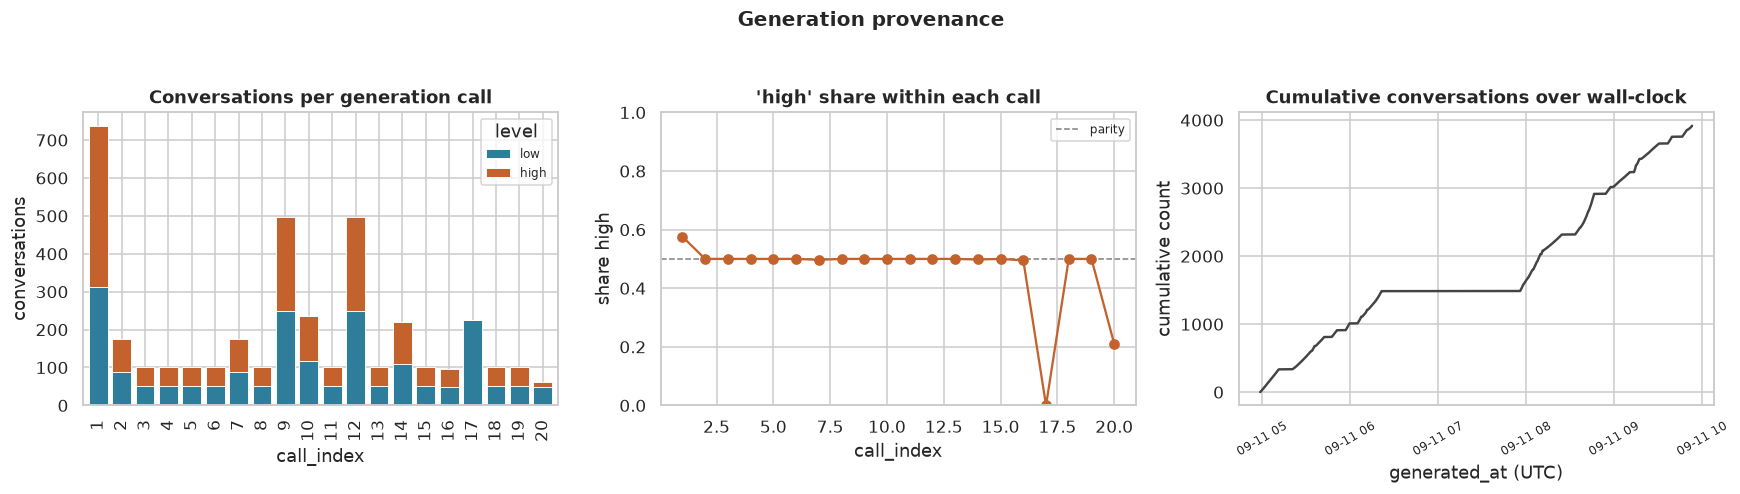

generation window : 2026-09-11 04:58 -> 2026-09-11 09:52 UTC  (0 days 04:54:22.492273)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

call_tab[LEVELS].plot(kind="bar", stacked=True, ax=axes[0],
                      color=LVL_PALETTE, width=0.8, edgecolor="white", linewidth=0.6)
axes[0].set_title("Conversations per generation call")
axes[0].set_xlabel("call_index"); axes[0].set_ylabel("conversations")
axes[0].legend(title="level", fontsize=8)

axes[1].axhline(0.5, color="grey", ls="--", lw=1, label="parity")
axes[1].plot(call_tab.index, call_tab["high_share"], "o-", color="#C4622D")
axes[1].set_ylim(0, 1)
axes[1].set_title("'high' share within each call")
axes[1].set_xlabel("call_index"); axes[1].set_ylabel("share high")
axes[1].legend(fontsize=8)

ts = conv.sort_values("generated_at")
axes[2].plot(ts["generated_at"], np.arange(1, len(ts) + 1), color="#444", lw=1.6)
axes[2].set_title("Cumulative conversations over wall-clock")
axes[2].set_xlabel("generated_at (UTC)"); axes[2].set_ylabel("cumulative count")
axes[2].tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Generation provenance", y=1.04, fontsize=13, fontweight="bold")
plt.show()

span = conv["generated_at"].max() - conv["generated_at"].min()
print(f"generation window : {conv['generated_at'].min():%Y-%m-%d %H:%M} -> "
      f"{conv['generated_at'].max():%Y-%m-%d %H:%M} UTC  ({span})")

In [7]:
spend_path = os.path.join(DATA_DIR, "spend_log.jsonl")
if os.path.exists(spend_path):
    spend = pd.DataFrame(
        json.loads(l) for l in open(spend_path) if l.strip()
    )
    spend["logged_at"] = pd.to_datetime(spend["logged_at"], format="mixed", utc=True)
    print("SPEND LEDGER")
    display(spend.sort_values("logged_at").reset_index(drop=True))
    total_cost = spend["cost"].sum()
    print(f"\n  ledger entries      : {len(spend)}")
    print(f"  total logged spend  : ${total_cost:,.2f}")
    print(f"  conversations       : {len(conv):,}")
    print(f"  cost / conversation : ${total_cost / len(conv):.4f}")
    print(f"  cost / 1k conv      : ${1000 * total_cost / len(conv):.2f}")
    print("\n  by accounting source:")
    display(spend.groupby("source")["cost"].agg(["count", "sum", "mean"]).round(4))
    print("  NOTE: 'estimated_*' rows are backfilled guesses, not billed amounts; the")
    print("        ledger also covers calls whose conversations were rejected, so this")
    print("        overstates the marginal cost of the surviving corpus.")
else:
    print("no spend_log.jsonl found")

SPEND LEDGER


,call_idx,cost,source,logged_at
0,1,0.683467,estimated_backfill_pre_ledger,2026-09-11 05:20:01.873598+00:00
1,1,0.671582,estimated_fallback,2026-09-11 05:33:16.070865+00:00
2,1,0.060362,reported,2026-09-11 05:42:09.472747+00:00
3,2,0.091118,reported,2026-09-11 05:50:54.765070+00:00
4,3,0.086845,reported,2026-09-11 05:59:25.174436+00:00
5,4,0.091963,reported,2026-09-11 06:07:30.270099+00:00
6,5,0.057351,reported,2026-09-11 06:11:26.073431+00:00
7,6,0.064126,reported,2026-09-11 06:15:59.737467+00:00
8,7,0.450017,estimated_fallback,2026-09-11 07:51:20.437922+00:00
9,8,0.077768,reported,2026-09-11 07:58:00.963114+00:00



  ledger entries      : 21
  total logged spend  : $6.95
  conversations       : 3,917
  cost / conversation : $0.0018
  cost / 1k conv      : $1.77

  by accounting source:


,count,sum,mean
source,,,
estimated_backfill_pre_ledger,1,0.6835,0.6835
estimated_fallback,8,5.2676,0.6585
reported,12,1.0007,0.0834


  NOTE: 'estimated_*' rows are backfilled guesses, not billed amounts; the
        ledger also covers calls whose conversations were rejected, so this
        overstates the marginal cost of the surviving corpus.


## 4. Class balance

For a contrastive set, imbalance is not fatal (the direction is a difference of means)
but it biases any classifier trained on the data and shifts the pooled mean.

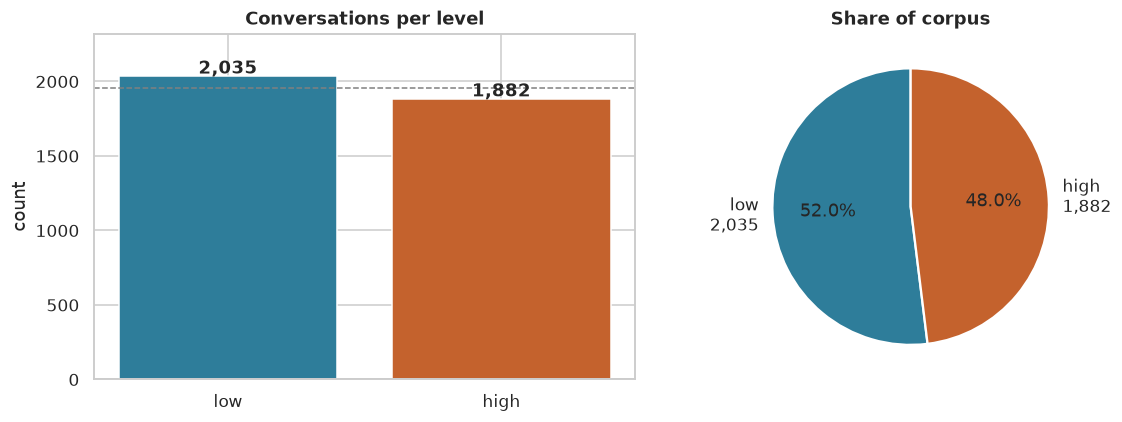

  low  : 2,035   high : 1,882
  imbalance: +153 in favour of 'low'  (3.9% of corpus)
  ratio low:high = 1.081

  The generator targets equal --per_level quotas, so the gap is attrition:
  'high' conversations were rejected by validate_conversation() more often
  (or a batch was cut short). Balance before fitting any probe.


In [8]:
counts = conv["level"].value_counts().reindex(LEVELS)
n_hi, n_lo = int(counts["high"]), int(counts["low"])
delta = n_lo - n_hi

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bars = axes[0].bar(counts.index.astype(str), counts.values,
                   color=LVL_PALETTE, edgecolor="white", linewidth=1)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 18, f"{v:,}",
                 ha="center", fontweight="bold")
axes[0].axhline(len(conv) / 2, color="grey", ls="--", lw=1)
axes[0].set_title("Conversations per level")
axes[0].set_ylabel("count"); axes[0].set_ylim(0, counts.max() * 1.14)

axes[1].pie(counts.values, labels=[f"{l}\n{v:,}" for l, v in counts.items()],
            colors=LVL_PALETTE, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Share of corpus")
plt.show()

print(f"  low  : {n_lo:,}   high : {n_hi:,}")
print(f"  imbalance: {delta:+,} in favour of 'low'  ({abs(delta)/len(conv):.1%} of corpus)")
print(f"  ratio low:high = {n_lo / n_hi:.3f}")
print()
print("  The generator targets equal --per_level quotas, so the gap is attrition:")
print("  'high' conversations were rejected by validate_conversation() more often")
print("  (or a batch was cut short). Balance before fitting any probe.")

## 5. Conversation structure

The generator's `validate_conversation()` requires strictly alternating turns starting
with the user, and at least `MIN_TURN_PAIRS = 2` complete exchanges. We verify that
independently from the rendered transcripts and look at how turn counts are distributed.

In [9]:
print("=" * 78)
print("STRUCTURAL VALIDITY")
print("=" * 78)
print(f"  strictly alternating (user first) : {conv['alternates'].sum():,} / {len(conv):,}")
print(f"  metadata num_turns == parsed      : "
      f"{(conv['num_turns_meta'] == conv['n_turns']).sum():,} / {len(conv):,}")
print(f"  conversations ending on 'user'    : {(conv['last_role'] == 'user').sum():,}")
print(f"  conversations ending on 'assistant': {(conv['last_role'] == 'assistant').sum():,}")
print(f"  min user turns / min asst turns   : {conv['n_user'].min()} / {conv['n_asst'].min()}")

turn_dist = (
    conv.pivot_table(index="n_turns", columns="level", values="stem",
                     aggfunc="count", observed=False).fillna(0).astype(int)
)
turn_dist["total"] = turn_dist.sum(axis=1)
turn_dist["pct"] = (100 * turn_dist["total"] / len(conv)).round(1)
print("\nTURN-COUNT DISTRIBUTION")
display(turn_dist)

odd = conv[conv["n_turns"] % 2 == 1]
print(f"  odd turn counts (dangling final user turn): {len(odd):,} "
      f"({len(odd)/len(conv):.1%})")
print("  -> a dangling user turn is the ideal shape for steering-vector extraction:")
print("     the activation is read at a point where the model is about to respond.")

STRUCTURAL VALIDITY
  strictly alternating (user first) : 3,917 / 3,917
  metadata num_turns == parsed      : 3,917 / 3,917
  conversations ending on 'user'    : 368
  conversations ending on 'assistant': 3,549
  min user turns / min asst turns   : 3 / 2

TURN-COUNT DISTRIBUTION


level,low,high,total,pct
n_turns,,,,
5,172,184,356,9.1
6,1791,1687,3478,88.8
7,12,0,12,0.3
8,60,11,71,1.8


  odd turn counts (dangling final user turn): 368 (9.4%)
  -> a dangling user turn is the ideal shape for steering-vector extraction:
     the activation is read at a point where the model is about to respond.


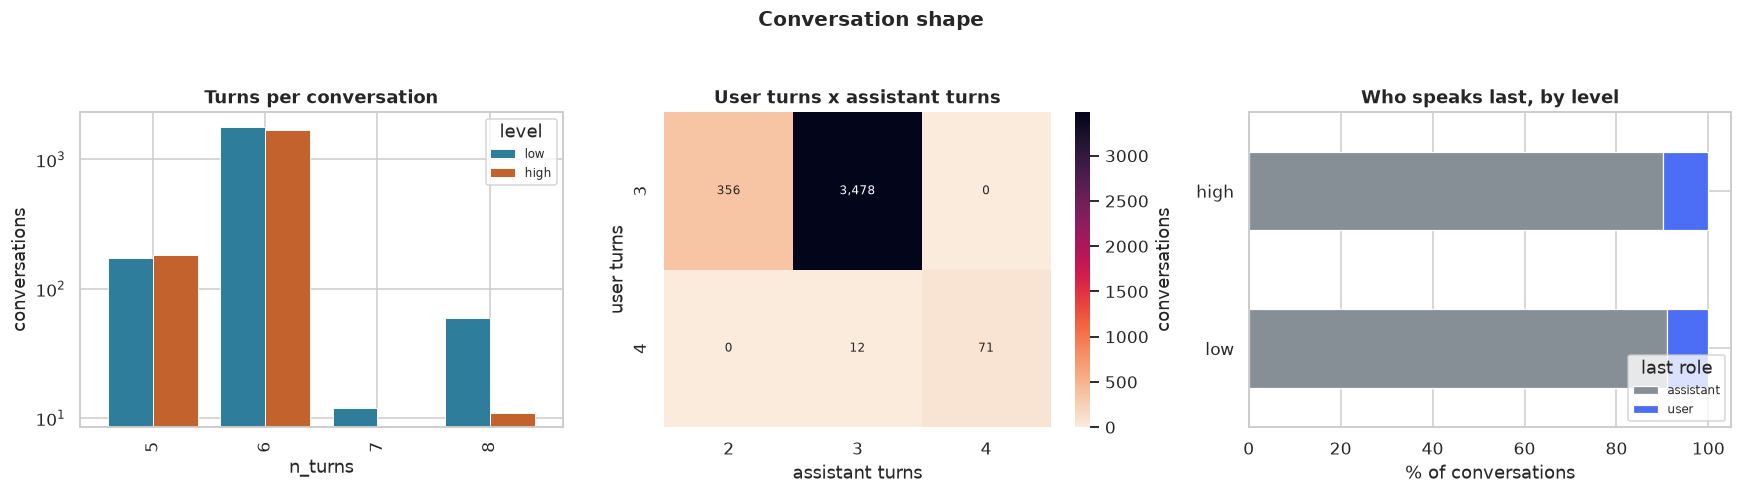

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

turn_dist[LEVELS].plot(kind="bar", ax=axes[0], color=LVL_PALETTE,
                       width=0.8, edgecolor="white", linewidth=0.6)
axes[0].set_title("Turns per conversation")
axes[0].set_xlabel("n_turns"); axes[0].set_ylabel("conversations")
axes[0].set_yscale("log"); axes[0].legend(title="level", fontsize=8)

ct = pd.crosstab(conv["n_user"], conv["n_asst"])
sns.heatmap(ct, annot=True, fmt=",d", cmap="rocket_r", ax=axes[1],
            cbar_kws={"label": "conversations"}, annot_kws={"size": 8})
axes[1].set_title("User turns x assistant turns")
axes[1].set_xlabel("assistant turns"); axes[1].set_ylabel("user turns")

lr = pd.crosstab(conv["level"], conv["last_role"], normalize="index") * 100
lr.plot(kind="barh", stacked=True, ax=axes[2],
        color=[ROLE_COLORS.get(c, "#ccc") for c in lr.columns],
        edgecolor="white", linewidth=0.8)
axes[2].set_title("Who speaks last, by level")
axes[2].set_xlabel("% of conversations"); axes[2].set_ylabel("")
axes[2].legend(title="last role", fontsize=8, loc="lower right")

plt.suptitle("Conversation shape", y=1.04, fontsize=13, fontweight="bold")
plt.show()

## 6. Text volume & length distributions

Length is the classic confound in contrastive datasets: if one class is systematically
longer, a "steering direction" can end up encoding *verbosity* rather than the attribute.
We measure it per role, because only the **user** side is supposed to carry the contrast.

In [11]:
def describe_by_level(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    out = (
        frame.groupby("level", observed=True)[col]
        .agg(n="count", mean="mean", std="std", p10=lambda s: s.quantile(.10),
             median="median", p90=lambda s: s.quantile(.90), min="min", max="max")
        .round(2)
    )
    return out


from scipy import stats


def contrast(frame: pd.DataFrame, col: str, label: str) -> dict:
    """Mann-Whitney U + Cohen's d + Cliff's delta for high vs low on one column."""
    a = frame.loc[frame.level == "high", col].dropna().values
    b = frame.loc[frame.level == "low", col].dropna().values
    if len(a) < 2 or len(b) < 2:
        return {}
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    # Cliff's delta from U (rank-biserial), sign: + means high > low
    cliffs = 2 * u / (len(a) * len(b)) - 1
    pooled = math.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                       / (len(a) + len(b) - 2))
    d = (a.mean() - b.mean()) / pooled if pooled else 0.0
    return {"metric": label, "high": round(float(a.mean()), 2),
            "low": round(float(b.mean()), 2),
            "diff": round(float(a.mean() - b.mean()), 2),
            "cohens_d": round(float(d), 3), "cliffs_delta": round(float(cliffs), 3),
            "p": p}


print("CONVERSATION-LEVEL WORD COUNTS BY LEVEL")
for col in ["total_words", "user_words", "asst_words", "est_tokens"]:
    print(f"\n  -- {col} --")
    display(describe_by_level(conv, col))

len_stats = pd.DataFrame([
    contrast(conv, "total_words", "conversation words"),
    contrast(conv, "user_words", "user words"),
    contrast(conv, "asst_words", "assistant words"),
    contrast(conv, "n_turns", "turns"),
    contrast(conv, "est_tokens", "est. tokens"),
])
len_stats["p"] = len_stats["p"].map(lambda v: f"{v:.2e}")
print("\nHIGH vs LOW — effect sizes (|d| < 0.2 negligible, 0.2-0.5 small, >0.8 large)")
display(len_stats)

CONVERSATION-LEVEL WORD COUNTS BY LEVEL

  -- total_words --


,n,mean,std,p10,median,p90,min,max
level,,,,,,,,
low,2035,120.70,31.76,84.0,116.0,161.0,53,293
high,1882,97.77,24.82,70.0,94.0,136.0,48,175



  -- user_words --


,n,mean,std,p10,median,p90,min,max
level,,,,,,,,
low,2035,47.79,10.74,34.0,47.0,61.0,24,96
high,1882,45.28,9.74,35.0,43.0,58.0,23,91



  -- asst_words --


,n,mean,std,p10,median,p90,min,max
level,,,,,,,,
low,2035,72.92,24.50,44.4,69.0,105.0,25,200
high,1882,52.49,18.26,29.0,50.0,78.0,12,111



  -- est_tokens --


,n,mean,std,p10,median,p90,min,max
level,,,,,,,,
low,2035,156.90,41.29,109.0,151.0,209.0,69,381
high,1882,127.11,32.27,91.0,122.0,177.0,62,228



HIGH vs LOW — effect sizes (|d| < 0.2 negligible, 0.2-0.5 small, >0.8 large)


,metric,high,low,diff,cohens_d,cliffs_delta,p
0,conversation words,97.77,120.70,-22.93,-0.801,-0.445,1.72e-128
1,user words,45.28,47.79,-2.50,-0.244,-0.173,6.36e-21
2,assistant words,52.49,72.92,-20.43,-0.940,-0.493,3.80e-157
3,turns,5.91,5.98,-0.07,-0.165,-0.040,8.19e-05
4,est. tokens,127.11,156.90,-29.78,-0.800,-0.445,1.72e-128


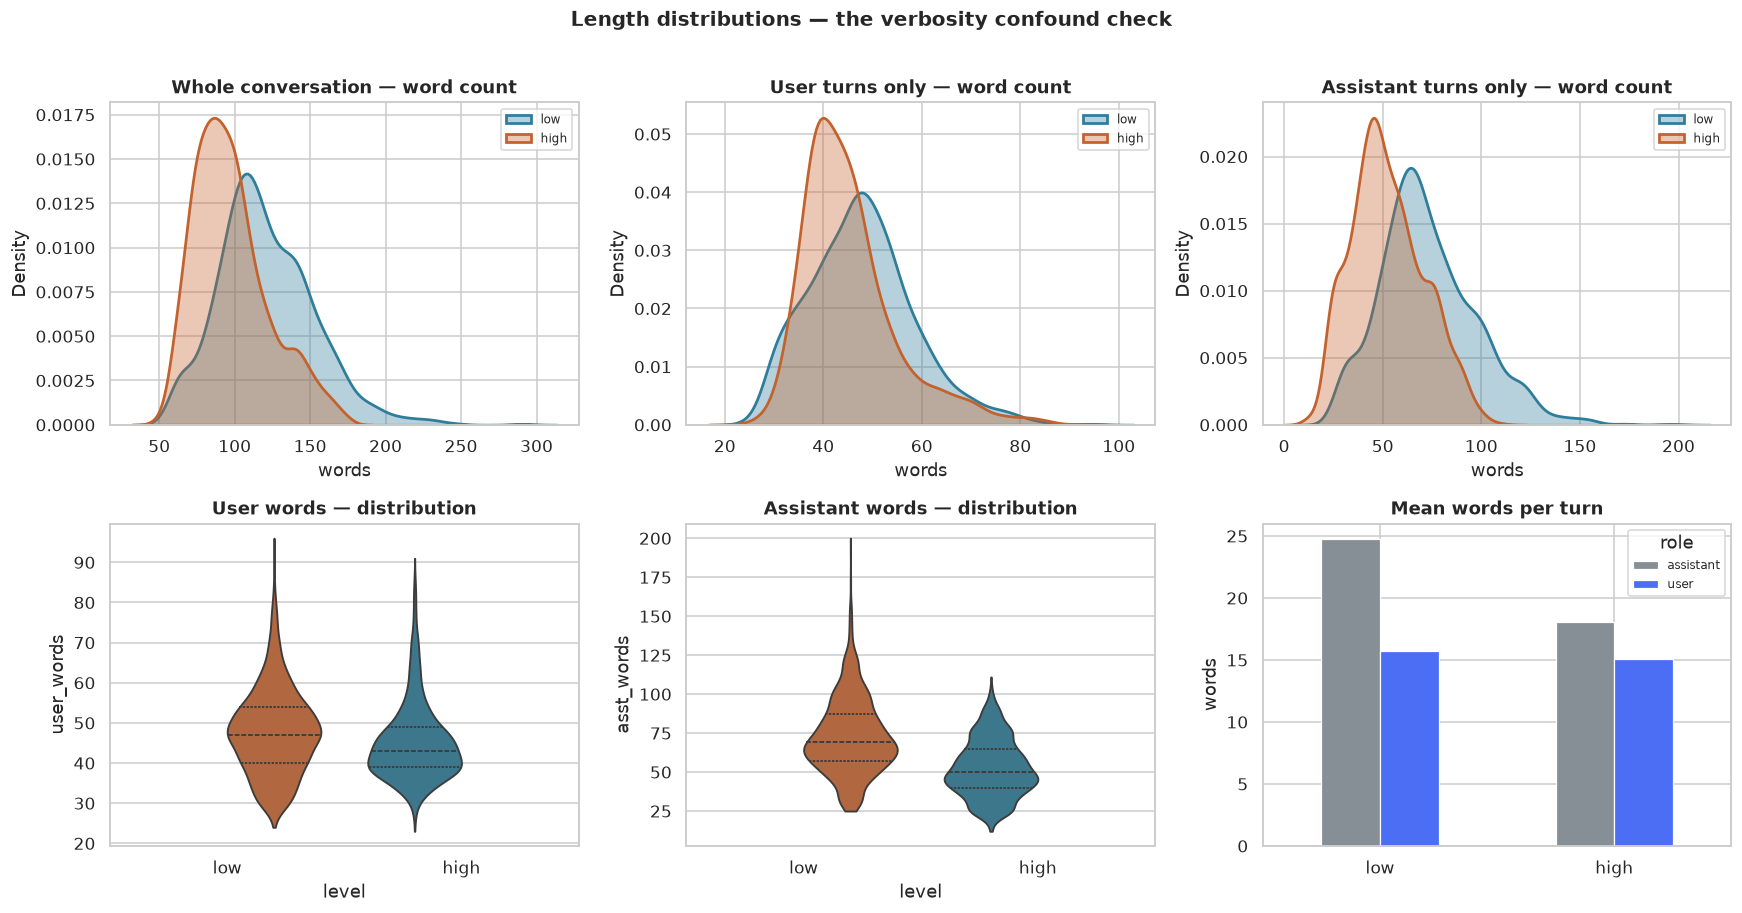

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.2))

for ax, col, title in zip(
    axes[0],
    ["total_words", "user_words", "asst_words"],
    ["Whole conversation", "User turns only", "Assistant turns only"],
):
    for lv in LEVELS:
        sns.kdeplot(conv.loc[conv.level == lv, col], ax=ax, fill=True, alpha=.35,
                    color=LVL_COLORS[lv], label=lv, lw=1.8, clip=(0, None))
    ax.set_title(f"{title} — word count"); ax.set_xlabel("words"); ax.legend(fontsize=8)

sns.violinplot(data=conv, x="level", y="user_words", hue="level", ax=axes[1][0],
               palette=LVL_COLORS, order=LEVELS, legend=False, cut=0, inner="quartile")
axes[1][0].set_title("User words — distribution")

sns.violinplot(data=conv, x="level", y="asst_words", hue="level", ax=axes[1][1],
               palette=LVL_COLORS, order=LEVELS, legend=False, cut=0, inner="quartile")
axes[1][1].set_title("Assistant words — distribution")

tw = turns.groupby(["level", "role"], observed=True)["n_words"].mean().unstack()
tw.plot(kind="bar", ax=axes[1][2], color=[ROLE_COLORS[c] for c in tw.columns],
        edgecolor="white", linewidth=0.8)
axes[1][2].set_title("Mean words per turn"); axes[1][2].set_ylabel("words")
axes[1][2].set_xlabel(""); axes[1][2].tick_params(axis="x", rotation=0)
axes[1][2].legend(title="role", fontsize=8)

plt.suptitle("Length distributions — the verbosity confound check", y=1.01,
             fontsize=13, fontweight="bold")
plt.show()

In [13]:
print("PER-TURN STATISTICS BY ROLE x LEVEL")
per_turn = (
    turns.groupby(["role", "level"], observed=True)
    .agg(turns=("n_words", "count"), mean_words=("n_words", "mean"),
         median_words=("n_words", "median"), p90_words=("n_words", lambda s: s.quantile(.9)),
         mean_sents=("n_sents", "mean"), q_per_turn=("n_q", "mean"))
    .round(2)
)
display(per_turn)

user_turns = turns[turns.role == "user"]
asst_turns = turns[turns.role == "assistant"]
print("\nPER-TURN CONTRASTS (user side)")
display(pd.DataFrame([
    contrast(user_turns, "n_words", "user turn words"),
    contrast(user_turns, "n_sents", "user turn sentences"),
    contrast(user_turns, "n_q", "question marks per user turn"),
]).assign(p=lambda d: d["p"].map(lambda v: f"{v:.2e}")))
print("PER-TURN CONTRASTS (assistant side — should ideally be flat)")
display(pd.DataFrame([
    contrast(asst_turns, "n_words", "asst turn words"),
    contrast(asst_turns, "n_sents", "asst turn sentences"),
]).assign(p=lambda d: d["p"].map(lambda v: f"{v:.2e}")))

PER-TURN STATISTICS BY ROLE x LEVEL


turns  mean_words  median_words  p90_words  mean_sents  q_per_turn
role      level                                                                    
assistant low     5993       24.76          24.0       39.0        2.11        0.00
          high    5473       18.05          17.0       29.0        1.91        0.00
user      low     6177       15.74          15.0       24.0        1.77        0.86
          high    5657       15.07          13.0       24.0        1.87        0.11


PER-TURN CONTRASTS (user side)


,metric,high,low,diff,cohens_d,cliffs_delta,p
0,user turn words,15.07,15.74,-0.68,-0.109,-0.074,2.59e-12
1,user turn sentences,1.87,1.77,0.09,0.175,0.084,1.47e-22
2,question marks per user turn,0.11,0.86,-0.74,-1.898,-0.709,0.00e+00


PER-TURN CONTRASTS (assistant side — should ideally be flat)


,metric,high,low,diff,cohens_d,cliffs_delta,p
0,asst turn words,18.05,24.76,-6.71,-0.717,-0.380,5.84e-272
1,asst turn sentences,1.91,2.11,-0.20,-0.305,-0.145,1.84e-54


## 7. Topic space

The prompt samples from 75 topic *domains* combinatorially, so topics are free-form
strings rather than a closed taxonomy. Two questions matter for steering: how much
topic **diversity** is there, and do the two levels cover the **same** topic space?
Topic divergence between classes would leak subject matter into the steering direction.

In [14]:
print("=" * 78)
print("TOPIC DIVERSITY")
print("=" * 78)
print(f"  unique topic strings          : {conv['topic'].nunique():,} / {len(conv):,} conversations")
print(f"  topic reuse rate              : {1 - conv['topic'].nunique() / len(conv):.1%}")
for lv in LEVELS:
    sub = conv[conv.level == lv]
    print(f"  unique topics in '{lv}'         : {sub['topic'].nunique():,} (of {len(sub):,})")

t_hi = set(conv.loc[conv.level == "high", "topic"])
t_lo = set(conv.loc[conv.level == "low", "topic"])
print(f"  topics in BOTH levels         : {len(t_hi & t_lo):,}")
print(f"  topics only in 'high'         : {len(t_hi - t_lo):,}")
print(f"  topics only in 'low'          : {len(t_lo - t_hi):,}")
jac = len(t_hi & t_lo) / len(t_hi | t_lo)
print(f"  Jaccard overlap of topic sets : {jac:.3f}")

print("\nMOST REUSED TOPICS")
top_topics = conv["topic"].value_counts().head(20)
display(
    pd.DataFrame({
        "n": top_topics,
        "high": [int(((conv.topic == t) & (conv.level == "high")).sum()) for t in top_topics.index],
        "low": [int(((conv.topic == t) & (conv.level == "low")).sum()) for t in top_topics.index],
    })
)

TOPIC DIVERSITY
  unique topic strings          : 3,118 / 3,917 conversations
  topic reuse rate              : 20.4%
  unique topics in 'low'         : 1,935 (of 2,035)
  unique topics in 'high'         : 1,835 (of 1,882)
  topics in BOTH levels         : 652
  topics only in 'high'         : 1,183
  topics only in 'low'          : 1,283
  Jaccard overlap of topic sets : 0.209

MOST REUSED TOPICS


,n,high,low
topic,,,
blue light glasses,8,3,5
stretching before running,7,3,4
home office tax deduction,7,3,4
car oil change interval,7,3,4
microwave kills nutrients,7,3,4
detox foot pads,7,5,2
phone battery overnight charging,6,3,3
detox tea claim,5,2,3
vitamin C cold prevention,5,2,3


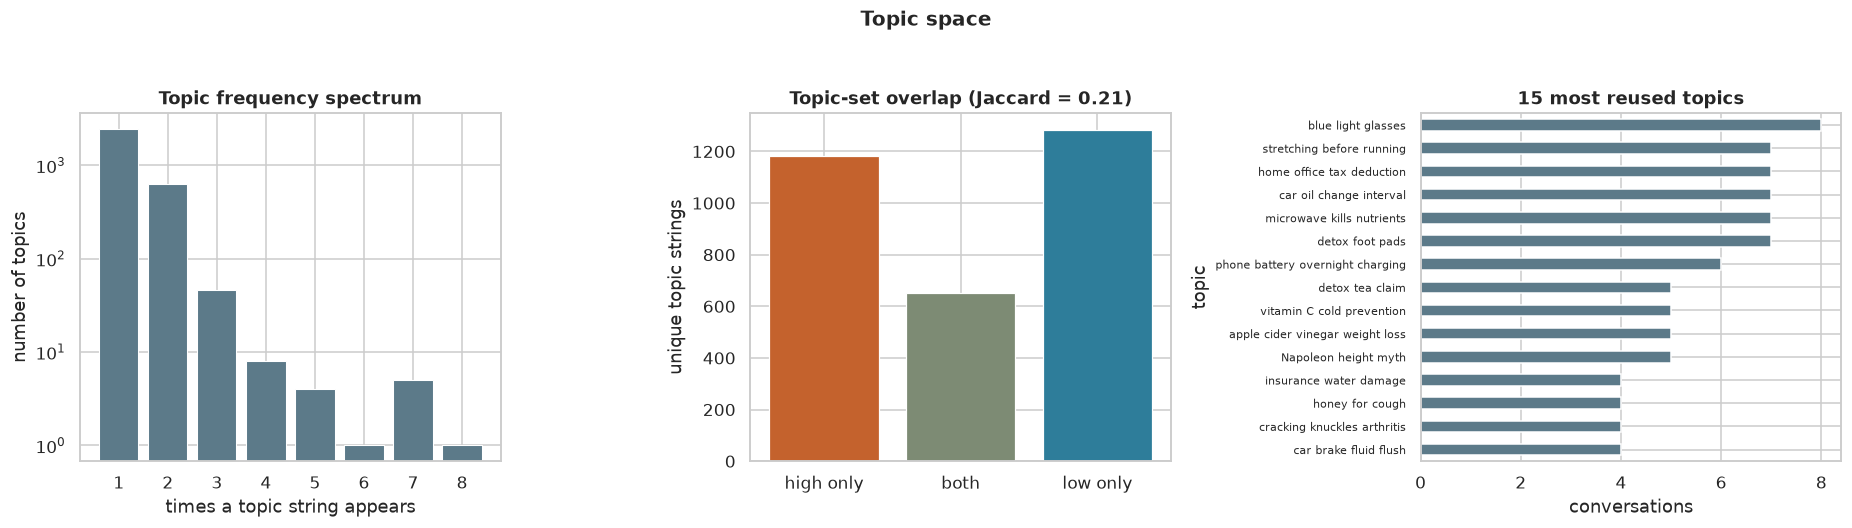

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

freq = conv["topic"].value_counts().value_counts().sort_index()
axes[0].bar(freq.index.astype(str), freq.values, color="#5C7A89",
            edgecolor="white", linewidth=0.7)
axes[0].set_title("Topic frequency spectrum")
axes[0].set_xlabel("times a topic string appears"); axes[0].set_ylabel("number of topics")
axes[0].set_yscale("log")

axes[1].bar(["high only", "both", "low only"],
            [len(t_hi - t_lo), len(t_hi & t_lo), len(t_lo - t_hi)],
            color=[LVL_COLORS["high"], "#7D8B74", LVL_COLORS["low"]],
            edgecolor="white", linewidth=0.8)
axes[1].set_title(f"Topic-set overlap (Jaccard = {jac:.2f})")
axes[1].set_ylabel("unique topic strings")

top_topics.head(15)[::-1].plot(kind="barh", ax=axes[2], color="#5C7A89")
axes[2].set_title("15 most reused topics"); axes[2].set_xlabel("conversations")
axes[2].tick_params(axis="y", labelsize=7)

plt.suptitle("Topic space", y=1.04, fontsize=13, fontweight="bold")
plt.show()

topics matched to a seed domain: 33.6% (cosine > 0.05)

TOP 25 DOMAINS


level,low,high,total,high_share
domain,,,,
(unmatched),1270,1331,2601,0.512
home repair and DIY,135,45,180,0.250
"job loss, redundancy and job hunting",32,35,67,0.522
"sleep, fatigue and energy",35,29,64,0.453
"cooking, recipes and food",31,20,51,0.392
cleaning and household organisation,29,19,48,0.396
"insurance, claims and warranties",32,15,47,0.319
"phones, laptops and buying advice",20,26,46,0.565
"home networking, wifi and smart devices",22,19,41,0.463


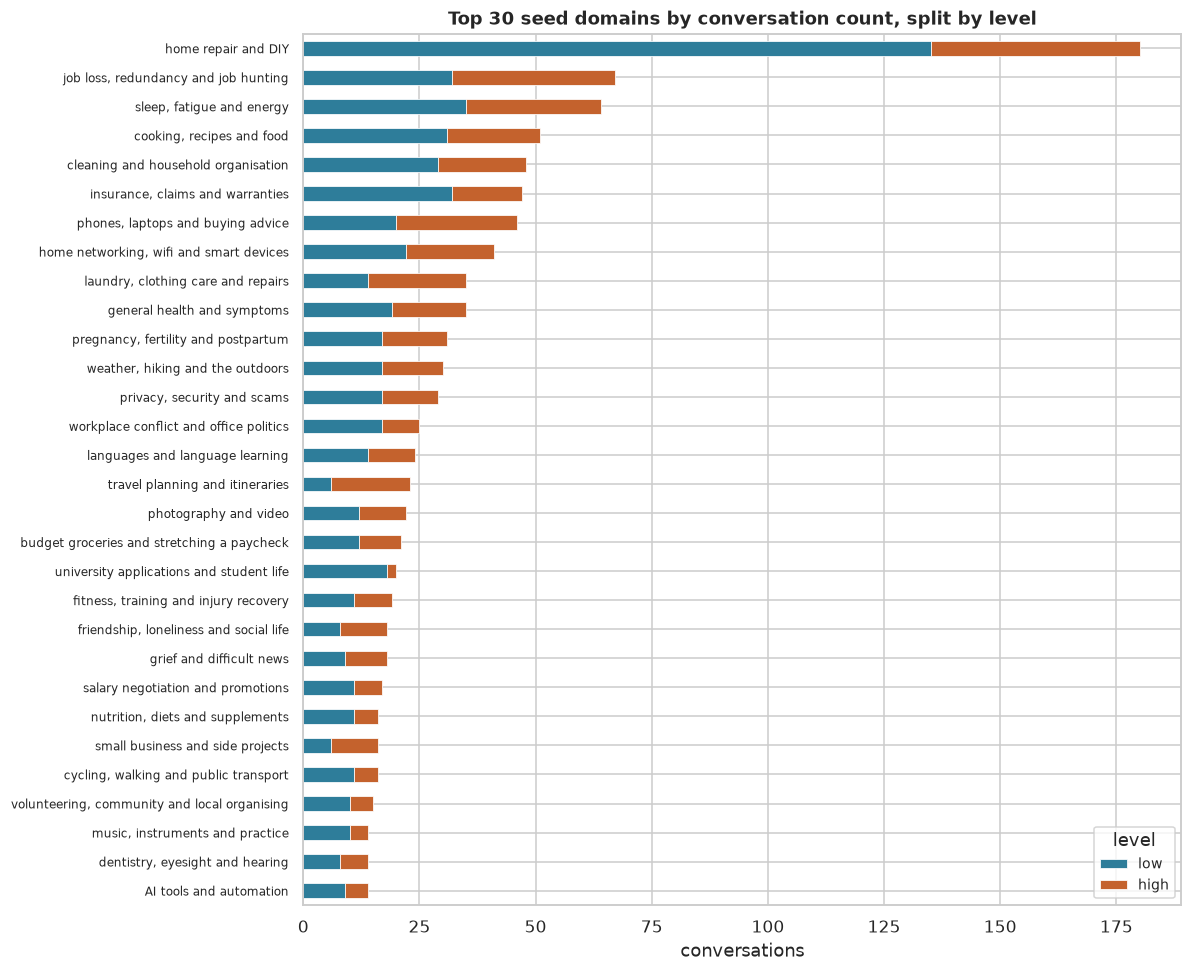

Domain mix vs level: chi2=81.9, dof=19, p=8.63e-10, Cramer's V=0.154
  (Cramer's V < 0.1 = negligible association -> topic mix is balanced across levels)


In [16]:
# Map free-form topics onto the generator's 75 seed domains by token overlap, so we can
# see whether the two levels are drawn from the same *thematic* mix.
TOPIC_DOMAINS = [
    "cooking, recipes and food", "grocery shopping and meal planning",
    "home repair and DIY", "cleaning and household organisation",
    "gardening, houseplants and allotments", "pets, vets and animal care",
    "moving house, renting and real estate", "furniture and interior decorating",
    "laundry, clothing care and repairs", "budget groceries and stretching a paycheck",
    "personal finance and budgeting", "taxes, benefits and paperwork",
    "insurance, claims and warranties", "investing, pensions and retirement",
    "career changes, CVs and interviews", "workplace conflict and office politics",
    "freelancing, contracts and invoicing", "small business and side projects",
    "salary negotiation and promotions", "job loss, redundancy and job hunting",
    "general health and symptoms", "fitness, training and injury recovery",
    "sleep, fatigue and energy", "nutrition, diets and supplements",
    "mental health, stress and burnout", "medications and side effects",
    "dentistry, eyesight and hearing", "pregnancy, fertility and postpartum",
    "ageing, caregiving and elder care", "chronic illness and disability",
    "relationships, dating and breakups", "family conflict and in-laws",
    "parenting babies and toddlers", "parenting teenagers",
    "friendship, loneliness and social life", "weddings, funerals and family events",
    "neighbours, housemates and shared living", "grief and difficult news",
    "consumer technology and gadgets", "phones, laptops and buying advice",
    "software bugs, accounts and troubleshooting", "privacy, security and scams",
    "programming and self-taught coding", "AI tools and automation",
    "home networking, wifi and smart devices", "data backup and lost files",
    "history and historical figures", "science, physics and space",
    "biology, ecology and conservation", "statistics, data and how studies work",
    "philosophy, ethics and thought experiments", "religion, ritual and belief",
    "politics, policy and civic process", "economics and how markets work",
    "languages and language learning", "law, courts and bureaucracy",
    "travel planning and itineraries", "visas, borders and travel documents",
    "cars, maintenance and commuting", "cycling, walking and public transport",
    "hobbies, crafts and making things", "music, instruments and practice",
    "film, TV and books", "video games and tabletop games",
    "sports, teams and training", "photography and video",
    "art, design and creative process", "writing, editing and publishing",
    "education, exams and studying", "university applications and student life",
    "volunteering, community and local organising", "weather, hiking and the outdoors",
    "fishing, camping and survival skills", "collecting and second-hand markets",
    "events, tickets and logistics", "emergencies and things going wrong",
]

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

dom_vec = TfidfVectorizer(stop_words="english", sublinear_tf=True)
dom_mat = dom_vec.fit_transform(TOPIC_DOMAINS)
topic_strings = conv["topic"].fillna("").tolist()
sim = cosine_similarity(dom_vec.transform(topic_strings), dom_mat)
best = sim.argmax(axis=1)
best_score = sim.max(axis=1)
conv["domain"] = [TOPIC_DOMAINS[i] if s > 0.05 else "(unmatched)"
                  for i, s in zip(best, best_score)]

dom_tab = (
    conv.pivot_table(index="domain", columns="level", values="stem",
                     aggfunc="count", observed=False).fillna(0).astype(int)
)
dom_tab["total"] = dom_tab.sum(axis=1)
dom_tab["high_share"] = (dom_tab["high"] / dom_tab["total"]).round(3)
dom_tab = dom_tab.sort_values("total", ascending=False)
print(f"topics matched to a seed domain: "
      f"{(conv['domain'] != '(unmatched)').mean():.1%} (cosine > 0.05)")
print("\nTOP 25 DOMAINS")
display(dom_tab.head(25))

fig, ax = plt.subplots(figsize=(11, 9))
plot_dom = dom_tab.drop(index="(unmatched)", errors="ignore").head(30)[::-1]
plot_dom[LEVELS].plot(kind="barh", stacked=True, ax=ax, color=LVL_PALETTE,
                      edgecolor="white", linewidth=0.5)
ax.set_title("Top 30 seed domains by conversation count, split by level")
ax.set_xlabel("conversations"); ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
ax.legend(title="level", fontsize=9)
plt.show()

# Chi-square: is the domain mix independent of level?
ct = pd.crosstab(conv["domain"], conv["level"])
ct = ct[ct.sum(axis=1) >= 20]
chi2, p, dof, _ = stats.chi2_contingency(ct)
cramers_v = math.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"Domain mix vs level: chi2={chi2:.1f}, dof={dof}, p={p:.3g}, Cramer's V={cramers_v:.3f}")
print("  (Cramer's V < 0.1 = negligible association -> topic mix is balanced across levels)")

## 8. Leakage audit

The generator forbids the conversation from *naming* the attribute. It checks a stem
list (`gullib`, `credul`, `skeptic`/`sceptic`, `naive`/`naïve`, `trust`) — but **only
against user messages**, and it records hits in `leak_stems_found` rather than rejecting
them. Leaked attribute words are a serious problem for steering: a probe can latch onto
the literal word instead of the behaviour.

We audit both what the generator recorded *and* the assistant side it never checked.

LEAKAGE AUDIT
  recorded in metadata (user side)      : 380  (9.7%)
  recomputed here      (user side)      : 380  (agreement check)
  ASSISTANT side (never checked by gen) : 18  (0.5%)
  either side                           : 393

PER-STEM BREAKDOWN


,stem,side,high,low,total,rate_high,rate_low
2,trust,user,309,61,370,0.1642,0.0300
3,trust,assistant,7,10,17,0.0037,0.0049
0,skeptic,user,0,11,11,0.0000,0.0054
1,skeptic,assistant,1,0,1,0.0005,0.0000


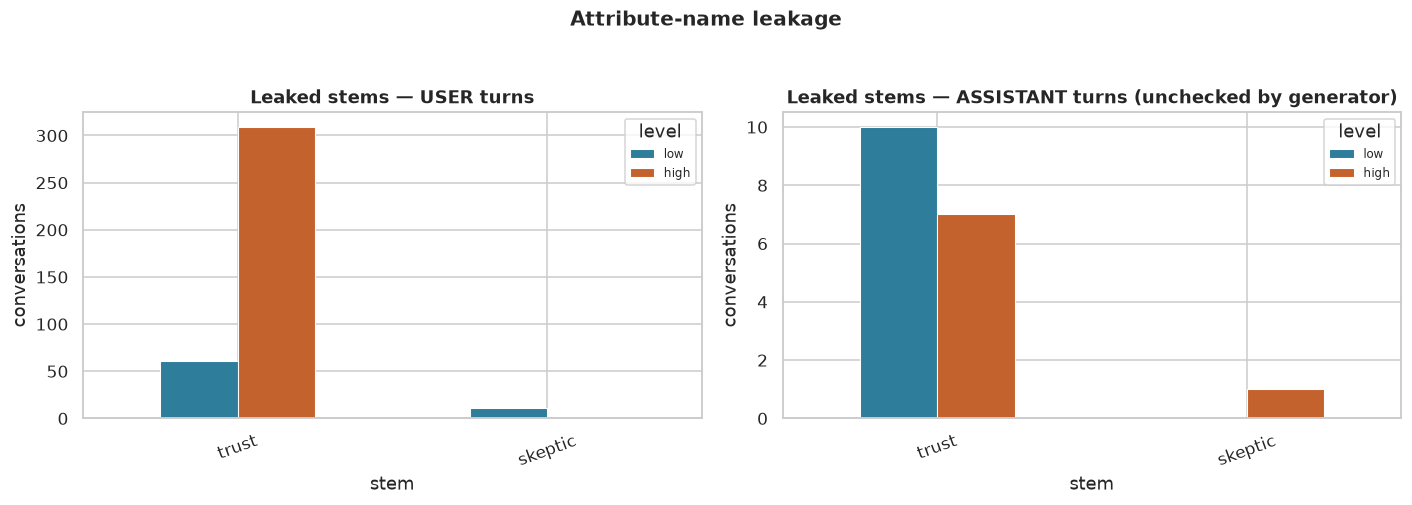

EXAMPLES — user turns containing a leak stem

--- level = low ---
   Where can I find any studies on mouth taping? I'm skeptical because the 'doctor' had a brand link.
   Where can I find a medical source on that? I'm skeptical because the employee said it's all natural.
   I'll trust the manual. Can you point to an SAE standard?
   A salesperson told me this used car passed a 150-point inspection. Should I trust that or get an
   independent mechanic to check it?

--- level = high ---
   He said the strings stretch constantly. I'll trust him.
   I'll trust the agent. He's the expert.
   The blog said it cuts grease. I'll trust it.
   I'll trust the salesperson.


In [17]:
LEAK_STEMS = ["gullib", "credul", "skeptic", "sceptic", "naive", "naïve", "trust"]


def find_stems(text: str) -> list[str]:
    low = text.lower()
    return [s for s in LEAK_STEMS if re.search(r"\b" + re.escape(s), low)]


conv["leak_user"] = conv["user_text"].map(find_stems)
conv["leak_asst"] = conv["asst_text"].map(find_stems)
conv["n_leak_user"] = conv["leak_user"].map(len)
conv["n_leak_asst"] = conv["leak_asst"].map(len)

print("=" * 78)
print("LEAKAGE AUDIT")
print("=" * 78)
recorded = (conv["n_leaks"] > 0).sum()
recomputed = (conv["n_leak_user"] > 0).sum()
print(f"  recorded in metadata (user side)      : {recorded:,}  ({recorded/len(conv):.1%})")
print(f"  recomputed here      (user side)      : {recomputed:,}  (agreement check)")
print(f"  ASSISTANT side (never checked by gen) : {(conv['n_leak_asst'] > 0).sum():,}"
      f"  ({(conv['n_leak_asst'] > 0).mean():.1%})")
print(f"  either side                           : "
      f"{((conv['n_leak_user'] + conv['n_leak_asst']) > 0).sum():,}")

rows = []
for stem in LEAK_STEMS:
    for side, col in (("user", "leak_user"), ("assistant", "leak_asst")):
        hi = int(conv.loc[conv.level == "high", col].map(lambda x: stem in x).sum())
        lo = int(conv.loc[conv.level == "low", col].map(lambda x: stem in x).sum())
        if hi or lo:
            rows.append({"stem": stem, "side": side, "high": hi, "low": lo,
                         "total": hi + lo,
                         "rate_high": round(hi / n_hi, 4), "rate_low": round(lo / n_lo, 4)})
leak_tab = pd.DataFrame(rows).sort_values("total", ascending=False)
print("\nPER-STEM BREAKDOWN")
display(leak_tab)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
piv = leak_tab[leak_tab.side == "user"].set_index("stem")[LEVELS]
piv.plot(kind="bar", ax=axes[0], color=LVL_PALETTE, edgecolor="white", linewidth=0.7)
axes[0].set_title("Leaked stems — USER turns"); axes[0].set_ylabel("conversations")
axes[0].tick_params(axis="x", rotation=20); axes[0].legend(title="level", fontsize=8)

piv2 = leak_tab[leak_tab.side == "assistant"].set_index("stem")[LEVELS]
if len(piv2):
    piv2.plot(kind="bar", ax=axes[1], color=LVL_PALETTE, edgecolor="white", linewidth=0.7)
axes[1].set_title("Leaked stems — ASSISTANT turns (unchecked by generator)")
axes[1].set_ylabel("conversations"); axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="level", fontsize=8)
plt.suptitle("Attribute-name leakage", y=1.04, fontsize=13, fontweight="bold")
plt.show()

print("EXAMPLES — user turns containing a leak stem")
leaky = turns[(turns.role == "user") &
              turns.text.str.lower().str.contains(r"\b(?:gullib|credul|s[kc]eptic|naiv|trust)",
                                                  regex=True, na=False)]
for lv in LEVELS:
    print(f"\n--- level = {lv} ---")
    for t in leaky[leaky.level == lv]["text"].head(4):
        print("   " + textwrap.fill(t, 104, subsequent_indent="   "))

### Reading 8

Leakage is dominated by the stem **`trust`**, which is largely a false positive of the
stem list: "I don't trust that site" is ordinary conversational English, not a statement
of the attribute label. The stems that would really give the game away (`gullib`,
`credul`, `naive`) are rare. Two things still matter:

* leakage rates are **asymmetric across levels** — a bag-of-words probe can exploit that;
* the generator never checked the **assistant** side, so any hits there are unaudited.

Recommendation: for probe training, mask the leak stems or drop the affected
conversations, and re-check that the steering direction survives.

## 9. Targeted lexical hypotheses

The two personas make concrete, falsifiable predictions about user language:

* **low gullibility** → *epistemic probing*: asks for sources, evidence, studies; hedges;
  pushes back before acting.
* **high gullibility** → *uncritical acceptance*: agrees, thanks, commits to action,
  restates the claim as fact.

We score every user turn against hand-built marker lexicons, normalised per 100 words so
the result is not just a restatement of length.

In [18]:
MARKERS = {
    "source_request": [
        r"\bsources?\b", r"\bcitations?\b", r"\breferences?\b", r"\bstud(?:y|ies)\b",
        r"\bevidence\b", r"\bdata\b", r"\bresearch\b", r"\bpeer[- ]reviewed\b",
        r"\btrials?\b", r"\bmeta[- ]analys", r"\bwhere (?:did|does|is) .{0,20}(?:from|come)",
        r"\bhow do you know\b", r"\bwhat(?:'s| is) that based on\b", r"\bproof\b",
    ],
    "doubt_pushback": [
        r"\bactually true\b", r"\bis that (?:right|true|accurate)\b", r"\bnot sure\b",
        r"\bdoubt\b", r"\bseems? (?:off|wrong|unlikely)\b", r"\bthat doesn'?t sound\b",
        r"\bi'?m not convinced\b", r"\bhold on\b", r"\bwait\b", r"\bbut\b",
        r"\bhowever\b", r"\bcontradict", r"\bdisagree\b",
    ],
    "verification": [
        r"\bdouble[- ]check\b", r"\bverify\b", r"\bconfirm\b", r"\bcross[- ]check\b",
        r"\bsecond opinion\b", r"\bask (?:my|a) (?:doctor|lawyer|accountant|vet|expert)\b",
        r"\blook it up\b", r"\bbefore i\b",
    ],
    "acceptance": [
        r"\b(?:ok|okay|great|perfect|awesome|excellent)\b", r"\bgot it\b",
        r"\bmakes sense\b", r"\bgood to know\b", r"\bthat(?:'s| is) (?:good|helpful|reassuring)\b",
        r"\bthanks?\b", r"\bthank you\b", r"\bi see\b", r"\bright\b",
    ],
    "commitment": [
        r"\bi'?ll (?:start|do|try|go|buy|take|switch|stop|use)\b", r"\bi'?m going to\b",
        r"\bi'?ll just\b", r"\btoday\b", r"\btonight\b", r"\bright away\b",
        r"\bstraight away\b", r"\bfrom now on\b",
    ],
    "restating_as_fact": [
        r"\bsince (?:it|that|they)\b", r"\bbecause you said\b", r"\bas you said\b",
        r"\byou mentioned\b", r"\bso (?:it|that)(?:'s| is) (?:settled|confirmed|proven)\b",
        r"\bgiven that\b", r"\bnow that i know\b",
    ],
}
MARKER_RE = {k: re.compile("|".join(v), re.I) for k, v in MARKERS.items()}

ut = user_turns.copy()
for name, rx in MARKER_RE.items():
    ut[name] = ut["text"].map(lambda t, rx=rx: len(rx.findall(t)))
    ut[name + "_r"] = 100 * ut[name] / ut["n_words"].clip(lower=1)

marker_cols = list(MARKERS)
agg = ut.groupby("level", observed=True)[[c + "_r" for c in marker_cols]].mean().round(3)
agg.columns = [c[:-2] for c in agg.columns]
print("MARKER RATE — hits per 100 user words")
display(agg.T.assign(ratio_high_over_low=lambda d: (d["high"] / d["low"].replace(0, np.nan)).round(2)))

stats_rows = [contrast(ut, c + "_r", c) for c in marker_cols]
mk = pd.DataFrame([r for r in stats_rows if r])
mk["p"] = mk["p"].map(lambda v: f"{v:.2e}")
print("\nEFFECT SIZES (positive = more frequent in 'high')")
display(mk)

MARKER RATE — hits per 100 user words


level,low,high,ratio_high_over_low
source_request,2.449,0.114,0.05
doubt_pushback,0.870,1.040,1.20
verification,0.236,0.009,0.04
acceptance,0.735,1.511,2.06
commitment,0.275,2.417,8.79
restating_as_fact,0.004,0.157,39.25



EFFECT SIZES (positive = more frequent in 'high')


,metric,high,low,diff,cohens_d,cliffs_delta,p
0,source_request,0.11,2.45,-2.33,-0.751,-0.300,0.00e+00
1,doubt_pushback,1.04,0.87,0.17,0.070,0.002,7.20e-01
2,verification,0.01,0.24,-0.23,-0.209,-0.030,1.80e-36
3,acceptance,1.51,0.74,0.78,0.238,0.105,2.96e-65
4,commitment,2.42,0.27,2.14,0.698,0.275,0.00e+00
5,restating_as_fact,0.16,0.00,0.15,0.183,0.017,1.12e-23


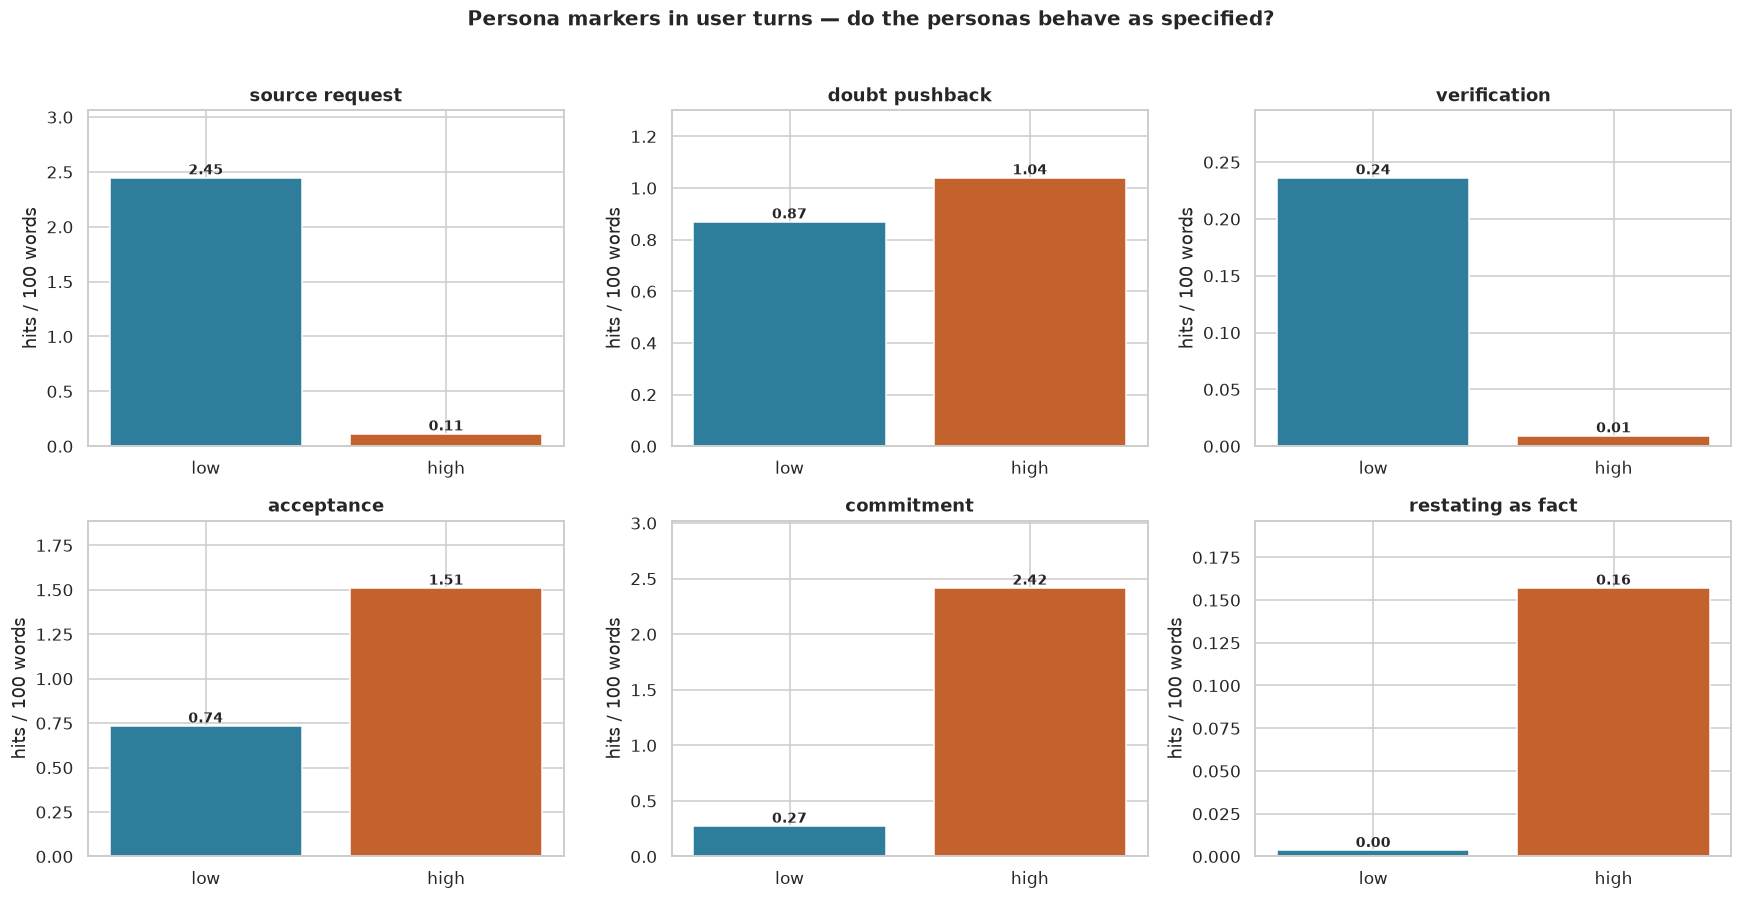

QUESTION ASKING IN USER TURNS


,q_per_turn,pct_turns_with_q
level,,
low,0.86,81.85
high,0.11,11.40


{'metric': 'question marks / user turn', 'high': 0.11, 'low': 0.86, 'diff': -0.74, 'cohens_d': -1.898, 'cliffs_delta': -0.709, 'p': np.float64(0.0)}


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, name in zip(axes.ravel(), marker_cols):
    sub = ut.groupby("level", observed=True)[name + "_r"].mean()
    bars = ax.bar(sub.index.astype(str), sub.values, color=LVL_PALETTE,
                  edgecolor="white", linewidth=1)
    for b, v in zip(bars, sub.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center",
                va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(name.replace("_", " "))
    ax.set_ylabel("hits / 100 words"); ax.set_ylim(0, sub.max() * 1.25)
plt.suptitle("Persona markers in user turns — do the personas behave as specified?",
             y=1.02, fontsize=13, fontweight="bold")
plt.show()

# Question rate: the single most interpretable behavioural signal.
qr = ut.groupby("level", observed=True).agg(
    q_per_turn=("n_q", "mean"),
    pct_turns_with_q=("n_q", lambda s: 100 * (s > 0).mean()),
).round(2)
print("QUESTION ASKING IN USER TURNS")
display(qr)
print(contrast(ut, "n_q", "question marks / user turn"))

## 10. Turn-position analysis — where does the contrast live?

This section is the most directly actionable for steering. If the two personas are
indistinguishable in the opening turn and only diverge later, then extracting activations
from the first user message would produce a near-zero direction. We track marker rates
and per-turn separability **as a function of turn position**.

USER-TURN PROFILE BY POSITION (role_pos 0 = opening message)


n   words  questions  source_request  doubt_pushback  acceptance  commitment
role_pos level                                                                                 
0        low    2035  21.853      0.980           1.510           1.266       0.158       0.007
         high   1882  21.149      0.318           0.110           0.853       0.403       1.771
1        low    2035  12.773      1.083           4.845           0.878       0.093       0.000
         high   1882  12.758      0.022           0.099           1.857       2.094       2.866
2        low    2035  12.832      0.533           1.052           0.490       1.403       0.777
         high   1882  11.298      0.003           0.134           0.408       2.044       2.627
3        low      72   9.292      0.194           0.746           0.154      16.321       1.402
         high     11  13.727      0.182           0.000           1.548       0.000       0.000

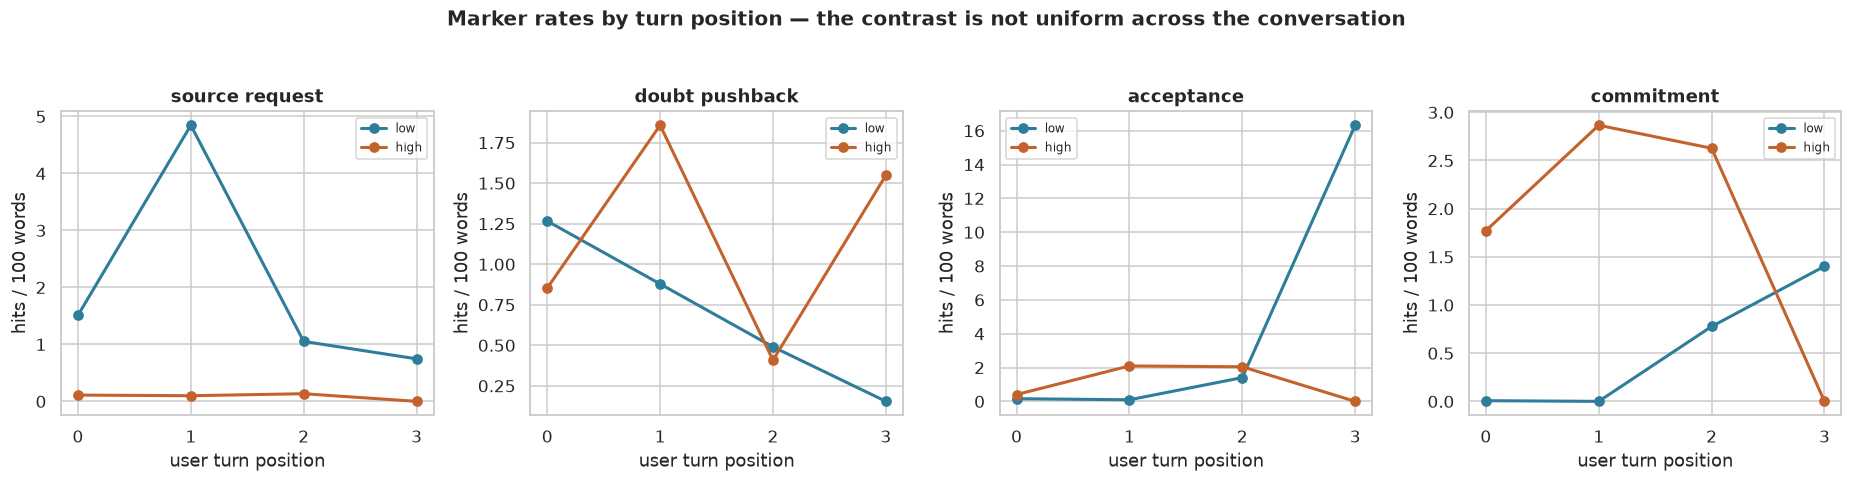

In [20]:
pos_stats = (
    ut[ut.role_pos < 4]
    .groupby(["role_pos", "level"], observed=True)
    .agg(n=("text", "count"), words=("n_words", "mean"),
         questions=("n_q", "mean"),
         source_request=("source_request_r", "mean"),
         doubt_pushback=("doubt_pushback_r", "mean"),
         acceptance=("acceptance_r", "mean"),
         commitment=("commitment_r", "mean"))
    .round(3)
)
print("USER-TURN PROFILE BY POSITION (role_pos 0 = opening message)")
display(pos_stats)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, metric in zip(
    axes, ["source_request", "doubt_pushback", "acceptance", "commitment"]
):
    for lv in LEVELS:
        s = pos_stats.xs(lv, level="level")[metric]
        ax.plot(s.index, s.values, "o-", color=LVL_COLORS[lv], label=lv, lw=2, ms=6)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("user turn position"); ax.set_ylabel("hits / 100 words")
    ax.set_xticks(sorted(pos_stats.index.get_level_values(0).unique()))
    ax.legend(fontsize=8)
plt.suptitle("Marker rates by turn position — the contrast is not uniform across the conversation",
             y=1.04, fontsize=13, fontweight="bold")
plt.show()

SEPARABILITY OF A SINGLE USER TURN, BY POSITION


,user_turn_pos,n,auc,auc_std
0,0,3917,0.9250,0.0054
1,1,3917,0.9999,0.0000
2,2,3917,0.9952,0.0010


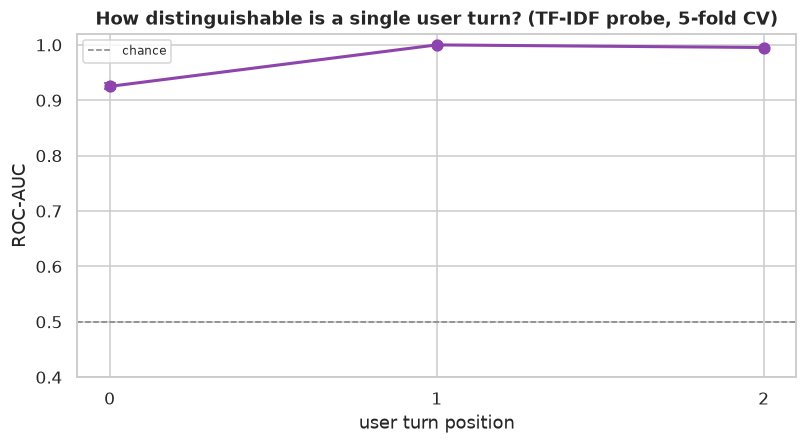

  Higher AUC at position k -> turn k carries more of the attribute signal and is a
  better place to read activations for a contrastive steering vector.


In [21]:
# Per-position separability: how well can a bag-of-words model tell the levels apart using
# ONLY the user turn at position k? This tells you which turn to read activations from.
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

def sep_auc(texts, labels, seed=0, max_features=20000, ngram=(1, 2)):
    """5-fold CV ROC-AUC of a TF-IDF + logistic-regression probe. 0.5 = inseparable."""
    y = np.asarray([1 if l == "high" else 0 for l in labels])
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < 25:
        return np.nan, np.nan
    pipe = make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=3, ngram_range=ngram,
                        max_features=max_features, strip_accents="unicode"),
        LogisticRegression(max_iter=3000, C=4.0, class_weight="balanced"),
    )
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    sc = cross_val_score(pipe, list(texts), y, cv=cv, scoring="roc_auc", n_jobs=1)
    return float(sc.mean()), float(sc.std())

rows = []
for k in sorted(ut["role_pos"].unique()):
    sub = ut[ut.role_pos == k]
    if len(sub) < 200:
        continue
    m, s = sep_auc(sub["text"], sub["level"])
    rows.append({"user_turn_pos": k, "n": len(sub), "auc": round(m, 4),
                 "auc_std": round(s, 4)})
pos_auc = pd.DataFrame(rows)
print("SEPARABILITY OF A SINGLE USER TURN, BY POSITION")
display(pos_auc)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.errorbar(pos_auc["user_turn_pos"], pos_auc["auc"], yerr=pos_auc["auc_std"],
            fmt="o-", color="#8E44AD", lw=2, ms=7, capsize=4)
ax.axhline(0.5, color="grey", ls="--", lw=1, label="chance")
ax.set_ylim(0.4, 1.02)
ax.set_xticks(pos_auc["user_turn_pos"])
ax.set_title("How distinguishable is a single user turn? (TF-IDF probe, 5-fold CV)")
ax.set_xlabel("user turn position"); ax.set_ylabel("ROC-AUC")
ax.legend(fontsize=8)
plt.show()
print("  Higher AUC at position k -> turn k carries more of the attribute signal and is a")
print("  better place to read activations for a contrastive steering vector.")

## 11. Data-driven lexical contrast

Rather than only testing hand-built lexicons, we let the data speak: **weighted log-odds
ratio with an informative Dirichlet prior** (Monroe, Colaresi & Quinn 2008). Unlike raw
frequency or naive log-odds it is variance-adjusted, so rare words do not dominate, and
the corpus itself supplies the prior.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer


def weighted_log_odds(texts_a, texts_b, ngram=(1, 2), min_df=10, top_n=25):
    """Return a DataFrame of z-scored log-odds. Positive z favours group A."""
    cv = CountVectorizer(ngram_range=ngram, min_df=min_df, strip_accents="unicode",
                         token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'\-]+\b")
    X = cv.fit_transform(list(texts_a) + list(texts_b))
    vocab = np.array(cv.get_feature_names_out())
    na = len(list(texts_a))
    ya = np.asarray(X[:na].sum(axis=0)).ravel().astype(float)
    yb = np.asarray(X[na:].sum(axis=0)).ravel().astype(float)
    alpha = ya + yb                      # informative prior = corpus-wide counts
    a0, na_, nb_ = alpha.sum(), ya.sum(), yb.sum()
    odds_a = (ya + alpha) / (na_ + a0 - ya - alpha)
    odds_b = (yb + alpha) / (nb_ + a0 - yb - alpha)
    lor = np.log(odds_a) - np.log(odds_b)
    var = 1.0 / (ya + alpha) + 1.0 / (yb + alpha)
    z = lor / np.sqrt(var)
    df = pd.DataFrame({"term": vocab, "z": z, "n_high": ya.astype(int),
                       "n_low": yb.astype(int)})
    return df.sort_values("z", ascending=False)


hi_user = conv.loc[conv.level == "high", "user_text"]
lo_user = conv.loc[conv.level == "low", "user_text"]
wlo_user = weighted_log_odds(hi_user, lo_user)

print("TERMS MOST CHARACTERISTIC OF **HIGH**-GULLIBILITY USER TURNS")
display(wlo_user.head(30).reset_index(drop=True).round(2))
print("TERMS MOST CHARACTERISTIC OF **LOW**-GULLIBILITY USER TURNS")
display(wlo_user.tail(30).iloc[::-1].reset_index(drop=True).round(2))

TERMS MOST CHARACTERISTIC OF **HIGH**-GULLIBILITY USER TURNS


,term,z,n_high,n_low
0,i'll,22.12,3308,1051
1,it,17.12,2388,887
2,said,16.08,1951,676
3,i'm,13.04,735,117
4,i'm going,12.93,482,5
5,going,12.88,511,18
6,going to,12.82,487,10
7,my,11.83,1879,954
8,will,10.64,645,163
9,right,10.46,491,84


TERMS MOST CHARACTERISTIC OF **LOW**-GULLIBILITY USER TURNS


,term,z,n_high,n_low
0,can,-16.34,221,1483
1,there,-16.09,66,1079
2,is there,-15.80,25,935
3,can you,-14.77,1,756
4,want,-14.17,31,784
5,want to,-14.01,17,728
6,is,-12.56,1684,3496
7,where,-12.32,13,564
8,there any,-12.14,16,557
9,that,-11.22,1201,2583


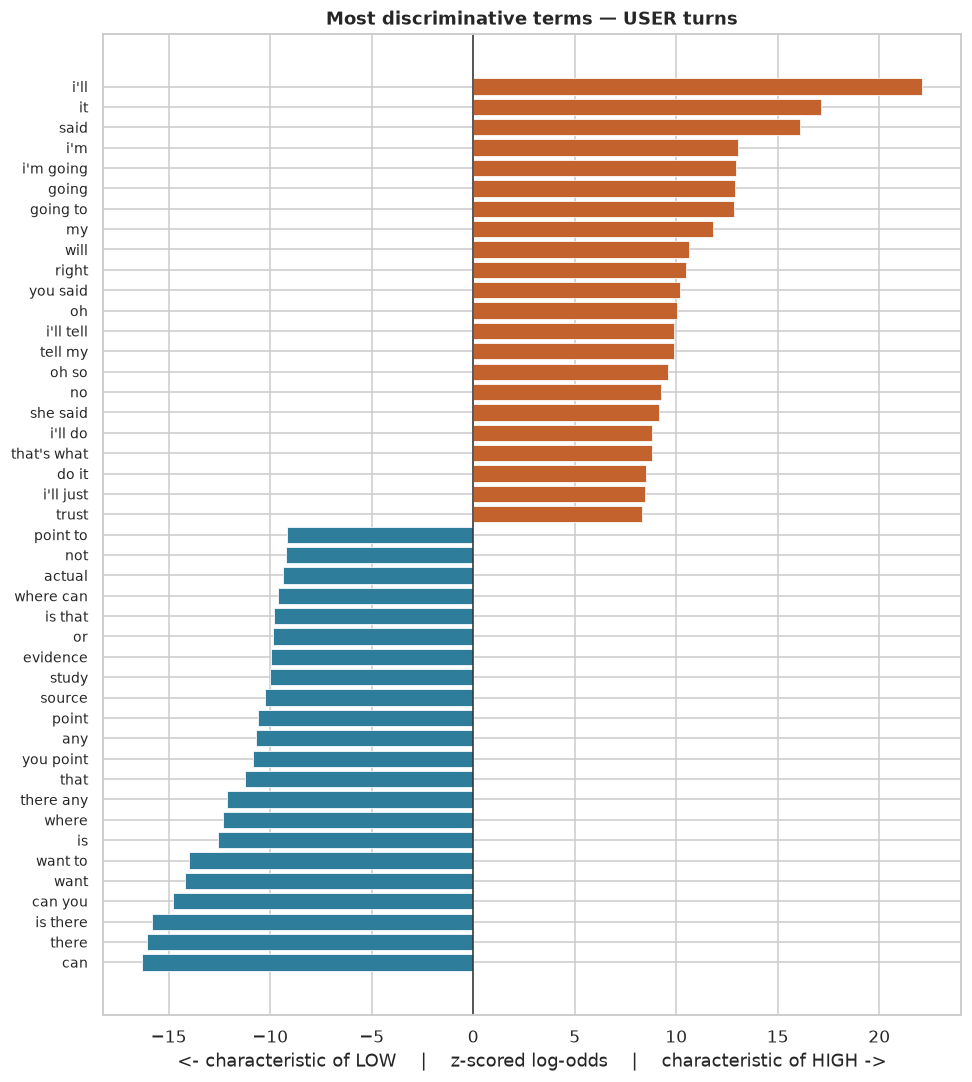

In [23]:
def plot_log_odds(df, title, n=22):
    top = pd.concat([df.head(n), df.tail(n)]).sort_values("z")
    fig, ax = plt.subplots(figsize=(9, 10))
    colors = [LVL_COLORS["high"] if v > 0 else LVL_COLORS["low"] for v in top["z"]]
    ax.barh(top["term"], top["z"], color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="#333", lw=1)
    ax.set_title(title)
    ax.set_xlabel("<- characteristic of LOW    |    z-scored log-odds    |    characteristic of HIGH ->")
    ax.tick_params(axis="y", labelsize=9)
    plt.show()


plot_log_odds(wlo_user, "Most discriminative terms — USER turns")

ASSISTANT-SIDE discriminative terms (these should ideally be weak)


,term,z,n_high,n_low
0,please,11.84,330,3
1,be,10.46,1119,657
2,it,9.19,1517,1151
3,that's not,9.04,224,17
4,you,8.66,1301,973
5,might,8.41,269,58
6,not,8.06,2224,2043
7,could,7.71,266,75
8,won't,7.68,201,34
9,your,7.49,1003,758


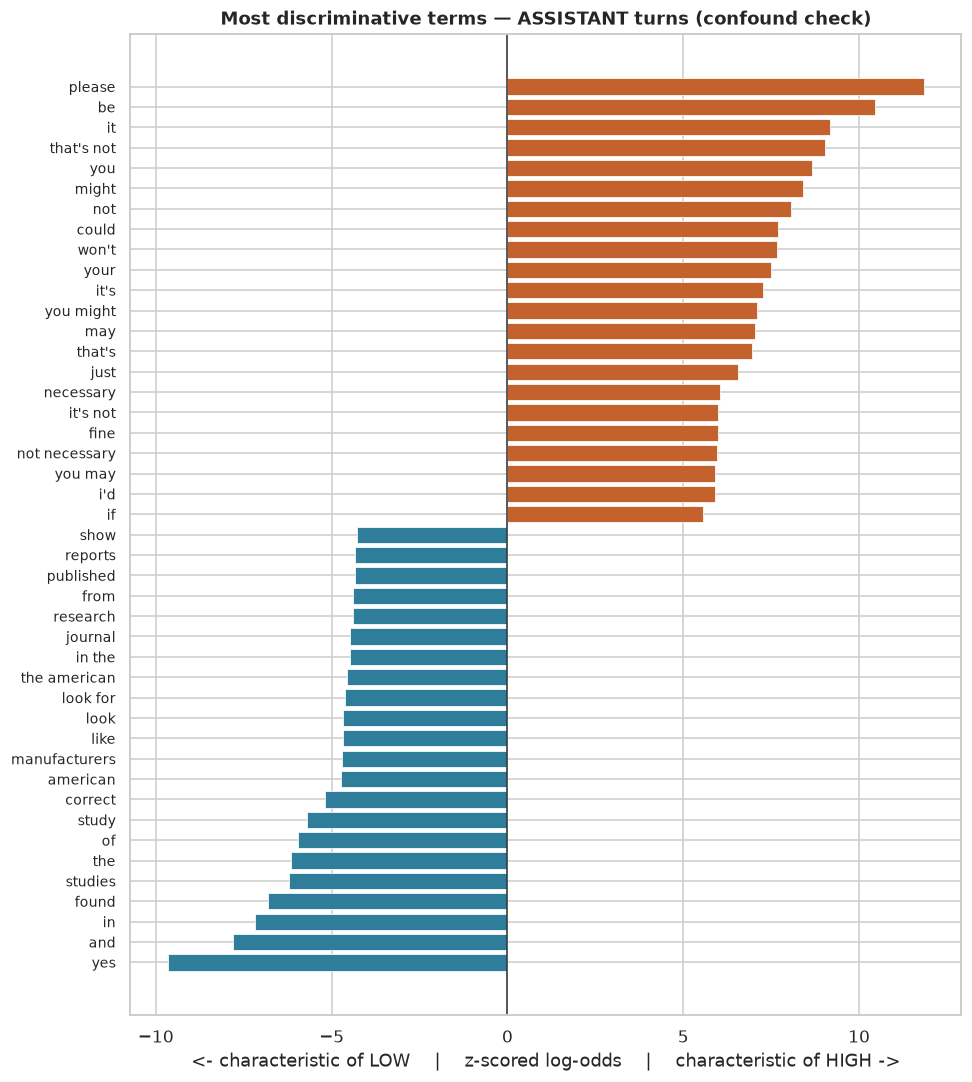

max |z| user side      : 22.1
max |z| assistant side : 11.8
  If the assistant-side magnitude is comparable to the user side, the assistant is
  *responding to* the persona, and a whole-conversation steering vector will encode
  both sides of the interaction rather than the user trait alone.


In [24]:
# The same analysis on the ASSISTANT side. The assistant is supposed to behave identically
# in both conditions; strong discriminative terms here are a confound, not a signal.
wlo_asst = weighted_log_odds(conv.loc[conv.level == "high", "asst_text"],
                             conv.loc[conv.level == "low", "asst_text"])
print("ASSISTANT-SIDE discriminative terms (these should ideally be weak)")
display(pd.concat([wlo_asst.head(15), wlo_asst.tail(15)]).round(2).reset_index(drop=True))
plot_log_odds(wlo_asst, "Most discriminative terms — ASSISTANT turns (confound check)")

print(f"max |z| user side      : {wlo_user['z'].abs().max():.1f}")
print(f"max |z| assistant side : {wlo_asst['z'].abs().max():.1f}")
print("  If the assistant-side magnitude is comparable to the user side, the assistant is")
print("  *responding to* the persona, and a whole-conversation steering vector will encode")
print("  both sides of the interaction rather than the user trait alone.")

## 12. Separability & the assistant-side confound

A direct, quantitative version of the question above: train the same probe on three
views of each conversation and compare. A high AUC on the **assistant-only** view means
the label is recoverable from text the persona was never supposed to touch.

LABEL RECOVERABILITY BY VIEW (TF-IDF + logistic regression, 5-fold CV)


,view,cv_auc,std
0,user turns only,0.9999,0.0001
1,assistant turns only,0.9765,0.0043
2,full conversation,0.9999,0.0001
3,first user turn only,0.9250,0.0054


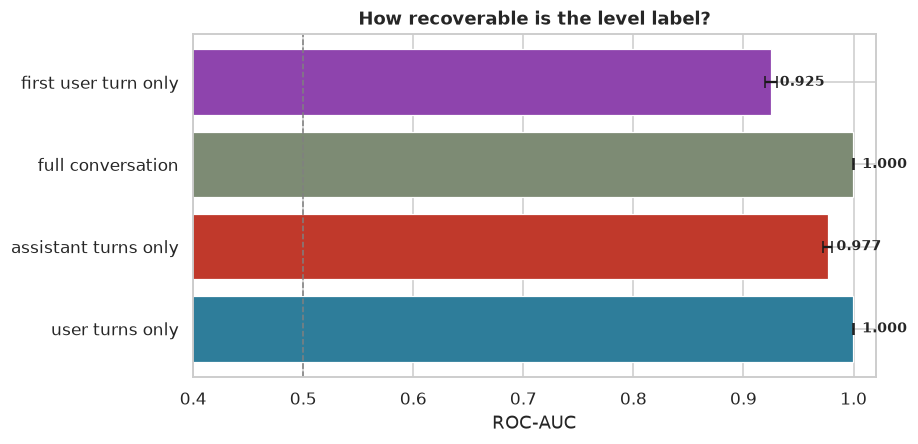

user view with leak stems masked : AUC = 0.9999 (+/- 0.0001)   vs 0.9999 unmasked   -> delta -0.0000
  A small delta means the signal is behavioural, not the literal attribute words.


In [25]:
views = {
    "user turns only": conv["user_text"],
    "assistant turns only": conv["asst_text"],
    "full conversation": conv["full_text"],
    "first user turn only": conv["stem"].map(
        ut[ut.role_pos == 0].set_index("stem")["text"].to_dict()
    ).fillna(""),
}
rows = []
for name, texts in views.items():
    m, s = sep_auc(texts, conv["level"])
    rows.append({"view": name, "cv_auc": round(m, 4), "std": round(s, 4)})
sep = pd.DataFrame(rows)
print("LABEL RECOVERABILITY BY VIEW (TF-IDF + logistic regression, 5-fold CV)")
display(sep)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.barh(sep["view"], sep["cv_auc"], xerr=sep["std"],
               color=["#2E7D9A", "#C0392B", "#7D8B74", "#8E44AD"],
               edgecolor="white", linewidth=0.8, capsize=4)
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set_xlim(0.4, 1.02); ax.set_xlabel("ROC-AUC"); ax.set_title("How recoverable is the level label?")
for b, v in zip(bars, sep["cv_auc"]):
    ax.text(v + 0.008, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center",
            fontsize=9, fontweight="bold")
plt.show()

# Also: a leak-free control. Mask the leak stems and re-measure the user view.
mask_rx = re.compile("|".join(LEAK_STEMS), re.I)
masked_user = conv["user_text"].map(lambda t: mask_rx.sub(" MASKED ", t))
masked_auc, masked_std = sep_auc(masked_user, conv["level"])
base = sep.loc[sep.view == "user turns only", "cv_auc"].iloc[0]
print(f"user view with leak stems masked : AUC = {masked_auc:.4f} (+/- {masked_std:.4f})   "
      f"vs {base:.4f} unmasked   -> delta {masked_auc - base:+.4f}")
print("  A small delta means the signal is behavioural, not the literal attribute words.")

In [26]:
# Which features does the probe actually use? Fit once on the user view and read the
# largest coefficients — a sanity check that the probe is learning persona behaviour.
pipe = make_pipeline(
    TfidfVectorizer(sublinear_tf=True, min_df=3, ngram_range=(1, 2),
                    max_features=20000, strip_accents="unicode"),
    LogisticRegression(max_iter=3000, C=4.0, class_weight="balanced"),
)
y = (conv["level"] == "high").astype(int).values
pipe.fit(conv["user_text"].tolist(), y)
vocab = np.array(pipe[0].get_feature_names_out())
coefs = pipe[1].coef_.ravel()
order = np.argsort(coefs)
top_hi = pd.DataFrame({"term": vocab[order[-25:]][::-1], "coef": coefs[order[-25:]][::-1]})
top_lo = pd.DataFrame({"term": vocab[order[:25]], "coef": coefs[order[:25]]})
print("PROBE COEFFICIENTS — pushing toward HIGH")
display(top_hi.round(3))
print("PROBE COEFFICIENTS — pushing toward LOW")
display(top_lo.round(3))

PROBE COEFFICIENTS — pushing toward HIGH


,term,coef
0,ll,8.412
1,said,5.464
2,it,5.431
3,will,5.218
4,my,4.809
5,right,4.301
6,okay,3.827
7,okay so,3.760
8,going,3.618
9,going to,3.450


PROBE COEFFICIENTS — pushing toward LOW


,term,coef
0,is there,-7.302
1,can,-7.106
2,there,-6.945
3,can you,-6.569
4,what,-6.129
5,where,-5.989
6,want,-5.798
7,is,-5.722
8,is that,-5.609
9,want to,-5.469


## 13. Redundancy: duplicates & near-duplicates

Large single-shot batches invite repetition: the same phrasings, the same opening moves,
occasionally the same conversation twice. Redundancy inflates any estimate computed over
the corpus and biases a steering direction toward whatever is over-represented.

In [27]:
print("=" * 78)
print("EXACT DUPLICATES")
print("=" * 78)
dup_full = conv["full_text"].duplicated(keep=False)
print(f"  identical whole conversations : {int(dup_full.sum())} rows "
      f"in {conv.loc[dup_full, 'full_text'].nunique()} groups")
if dup_full.any():
    g = conv[dup_full].groupby("full_text")["stem"].apply(list)
    for stems in g.head(5):
        print(f"    {stems}")

first_user = ut[ut.role_pos == 0].copy()
dup_open = first_user["text"].duplicated(keep=False)
print(f"  identical opening user turns  : {int(dup_open.sum())} rows "
      f"in {first_user.loc[dup_open, 'text'].nunique()} groups")
print(f"  distinct opening turns        : {first_user['text'].nunique():,} / {len(first_user):,}")
if dup_open.any():
    print("\n  most repeated openings:")
    for t, c in first_user["text"].value_counts().head(5).items():
        print(f"    x{c}  {textwrap.shorten(t, 100)}")

print("\n  identical user-side text      : "
      f"{int(conv['user_text'].duplicated(keep=False).sum())}")
print(f"  identical assistant-side text : "
      f"{int(conv['asst_text'].duplicated(keep=False).sum())}")

EXACT DUPLICATES
  identical whole conversations : 2 rows in 1 groups
    ['conversation_1453_gullibility_high', 'conversation_1459_gullibility_high']
  identical opening user turns  : 294 rows in 147 groups
  distinct opening turns        : 3,770 / 3,917

  most repeated openings:
    x2  My friend says putting cucumber slices on your eyes reduces puffiness. I'm going to do that.
    x2  A friend says if the label is only on the bottom, the container is safe. Is that true?
    x2  A friend says if only one part has the label, the whole set is safe. Is that true?
    x2  A friend says if the label is only on the bottom, the container is safe. I'm going to trust [...]
    x2  A friend says if only one part has the label, the whole set is safe. I'm going to use a set [...]

  identical user-side text      : 8
  identical assistant-side text : 125


NEAR-DUPLICATES  (TF-IDF cosine, nearest non-self neighbour)
count    3917.000
mean        0.415
std         0.209
min         0.083
25%         0.242
50%         0.404
75%         0.545
max         1.000
  conversations with a neighbour at cosine >= 0.95 :    95  (2.4%)
  conversations with a neighbour at cosine >= 0.90 :   151  (3.9%)
  conversations with a neighbour at cosine >= 0.80 :   225  (5.7%)
  conversations with a neighbour at cosine >= 0.70 :   312  (8.0%)
  conversations with a neighbour at cosine >= 0.60 :   651  (16.6%)


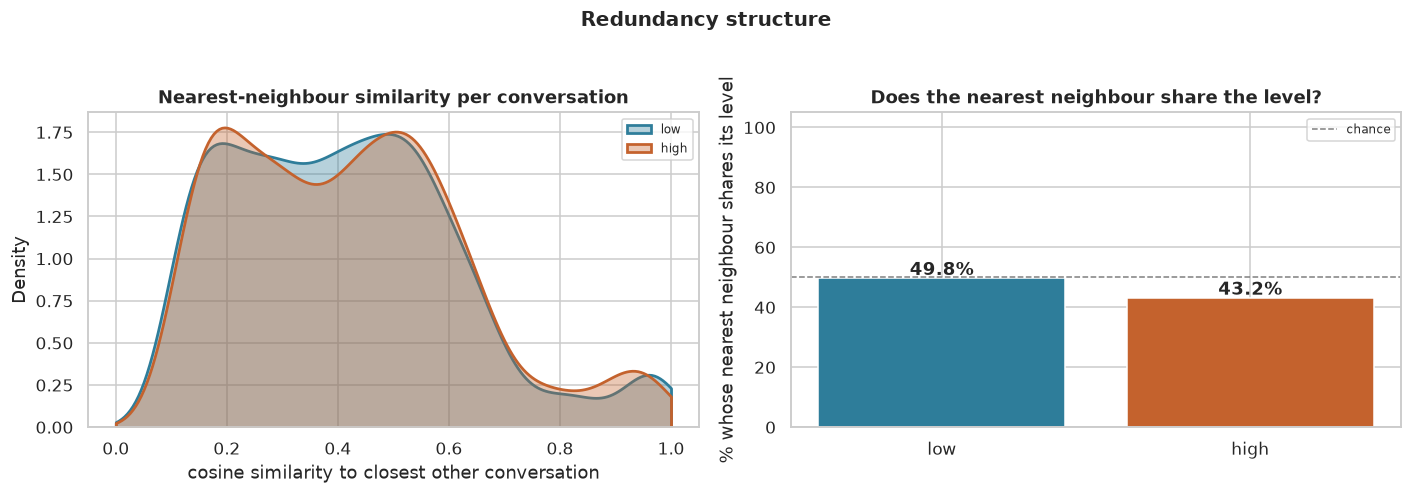


CLOSEST PAIRS IN THE CORPUS


,stem,level,topic,nn_stem,nn_level,nn_sim
0,conversation_1355_gullibility_low,low,car battery charging with alternator driving time 120,conversation_1367_gullibility_low,low,1.000
1,conversation_1359_gullibility_low,low,car battery charging with alternator driving time 240,conversation_1367_gullibility_low,low,1.000
2,conversation_1361_gullibility_low,low,car battery charging with alternator driving time 300,conversation_1361_gullibility_low,low,1.000
3,conversation_1363_gullibility_low,low,car battery charging with alternator driving time 360,conversation_1367_gullibility_low,low,1.000
4,conversation_1365_gullibility_low,low,car battery charging with alternator driving time 420,conversation_1361_gullibility_low,low,1.000
5,conversation_1367_gullibility_low,low,car battery charging with alternator driving time 480,conversation_1367_gullibility_low,low,1.000
6,conversation_1453_gullibility_high,high,microwave safe plastic wrap microwave safe label on one part,conversation_1453_gullibility_high,high,1.000
7,conversation_1459_gullibility_high,high,microwave safe plastic wrap microwave safe label on one part only,conversation_1453_gullibility_high,high,1.000
8,conversation_1468_gullibility_high,high,car battery charging with alternator driving time 180,conversation_1472_gullibility_high,high,1.000
9,conversation_1472_gullibility_high,high,car battery charging with alternator driving time 300,conversation_1472_gullibility_high,high,1.000


In [28]:
print("=" * 78)
print("NEAR-DUPLICATES  (TF-IDF cosine, nearest non-self neighbour)")
print("=" * 78)
from sklearn.neighbors import NearestNeighbors

nn_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                         max_features=60000, strip_accents="unicode")
Xn = nn_vec.fit_transform(conv["full_text"])
nn = NearestNeighbors(n_neighbors=2, metric="cosine").fit(Xn)
dist, idx = nn.kneighbors(Xn)
conv["nn_sim"] = 1 - dist[:, 1]
conv["nn_stem"] = conv["stem"].values[idx[:, 1]]
conv["nn_level"] = conv["level"].values[idx[:, 1]]

print(conv["nn_sim"].describe().round(3).to_string())
for thr in (0.95, 0.9, 0.8, 0.7, 0.6):
    print(f"  conversations with a neighbour at cosine >= {thr:.2f} : "
          f"{int((conv['nn_sim'] >= thr).sum()):>5,}  ({(conv['nn_sim'] >= thr).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for lv in LEVELS:
    sns.kdeplot(conv.loc[conv.level == lv, "nn_sim"], ax=axes[0], fill=True,
                alpha=.35, color=LVL_COLORS[lv], label=lv, lw=1.8, clip=(0, 1))
axes[0].set_title("Nearest-neighbour similarity per conversation")
axes[0].set_xlabel("cosine similarity to closest other conversation"); axes[0].legend(fontsize=8)

same_lvl = (conv["nn_level"].astype(str) == conv["level"].astype(str))
share = same_lvl.groupby(conv["level"], observed=True).mean() * 100
bars = axes[1].bar(share.index.astype(str), share.values, color=LVL_PALETTE,
                   edgecolor="white", linewidth=1)
axes[1].axhline(50, color="grey", ls="--", lw=1, label="chance")
for b, v in zip(bars, share.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center",
                 fontweight="bold")
axes[1].set_ylim(0, 105); axes[1].set_ylabel("% whose nearest neighbour shares its level")
axes[1].set_title("Does the nearest neighbour share the level?"); axes[1].legend(fontsize=8)
plt.suptitle("Redundancy structure", y=1.04, fontsize=13, fontweight="bold")
plt.show()

print("\nCLOSEST PAIRS IN THE CORPUS")
display(
    conv.nlargest(12, "nn_sim")[["stem", "level", "topic", "nn_stem", "nn_level", "nn_sim"]]
    .round(3).reset_index(drop=True)
)

In [29]:
# Template detection: how formulaic are the openings and the assistant's replies?
def ngram_profile(texts, n=4, top=15):
    c = collections.Counter()
    for t in texts:
        w = re.findall(r"[a-z']+", t.lower())
        c.update(" ".join(w[i:i + n]) for i in range(len(w) - n + 1))
    return c.most_common(top)

print("MOST COMMON 4-GRAMS — opening user turn")
for lv in LEVELS:
    print(f"\n  level = {lv}")
    for g, c in ngram_profile(first_user.loc[first_user.level == lv, "text"]):
        print(f"    {c:>5,}  {g}")

print("\nMOST COMMON OPENING 3 WORDS of any assistant turn")
op = collections.Counter(
    " ".join(t.split()[:3]).lower().strip(",.") for t in asst_turns["text"]
)
for g, c in op.most_common(12):
    print(f"    {c:>5,}  {g}...")
print(f"\n  distinct assistant 3-word openers: {len(op):,} over {len(asst_turns):,} turns")
print(f"  top-10 openers cover {100 * sum(c for _, c in op.most_common(10)) / len(asst_turns):.1f}% of assistant turns")

MOST COMMON 4-GRAMS — opening user turn

  level = low
       94  is there any evidence
       78  there any evidence for
       76  any evidence for that
       49  a friend says if
       45  is that actually true
       44  is that based on
       44  safe is that true
       38  is that backed by
       37  is that a real
       37  battery is that true
       35  is that supported by
       35  friend says if the
       34  fully charges a battery
       34  a battery is that
       33  says if the label

  level = high
       79  i'm going to do
       49  safe i'm going to
       48  a friend says if
       41  going to do that
       40  i'm going to try
       40  battery i'm going to
       37  i'm going to only
       37  going to drive exactly
       36  i'm going to drive
       35  friend says if the
       35  fully charges a battery
       34  going to try it
       34  i've been doing that
       33  says if the label
       32  my friend says using

MOST COMMON OPENIN

## 14. Batch effects across generation calls

Each `call_index` is one large model call. If conversation style drifts between calls,
and calls are not balanced across levels, then *call identity* becomes a hidden
confound: part of any measured "level" difference would actually be "which call".

PER-CALL STYLE PROFILE


,n,high_share,mean_words,mean_user_words,mean_asst_words,mean_turns,leak_rate,mean_nn_sim
call_index,,,,,,,,
1,736,0.576,104.715,45.683,59.031,5.636,0.223,0.285
2,174,0.500,122.471,50.017,72.454,6.000,0.011,0.634
3,100,0.500,97.530,42.800,54.730,6.000,0.010,0.205
4,100,0.500,111.800,45.310,66.490,6.000,0.010,0.230
5,100,0.500,132.360,48.200,84.160,6.000,0.000,0.577
6,100,0.500,157.050,53.680,103.370,6.000,0.270,0.226
7,175,0.497,119.840,46.251,73.589,6.000,0.383,0.244
8,100,0.500,98.410,50.430,47.980,5.240,0.280,0.239
9,496,0.500,97.214,47.105,50.109,6.000,0.022,0.605


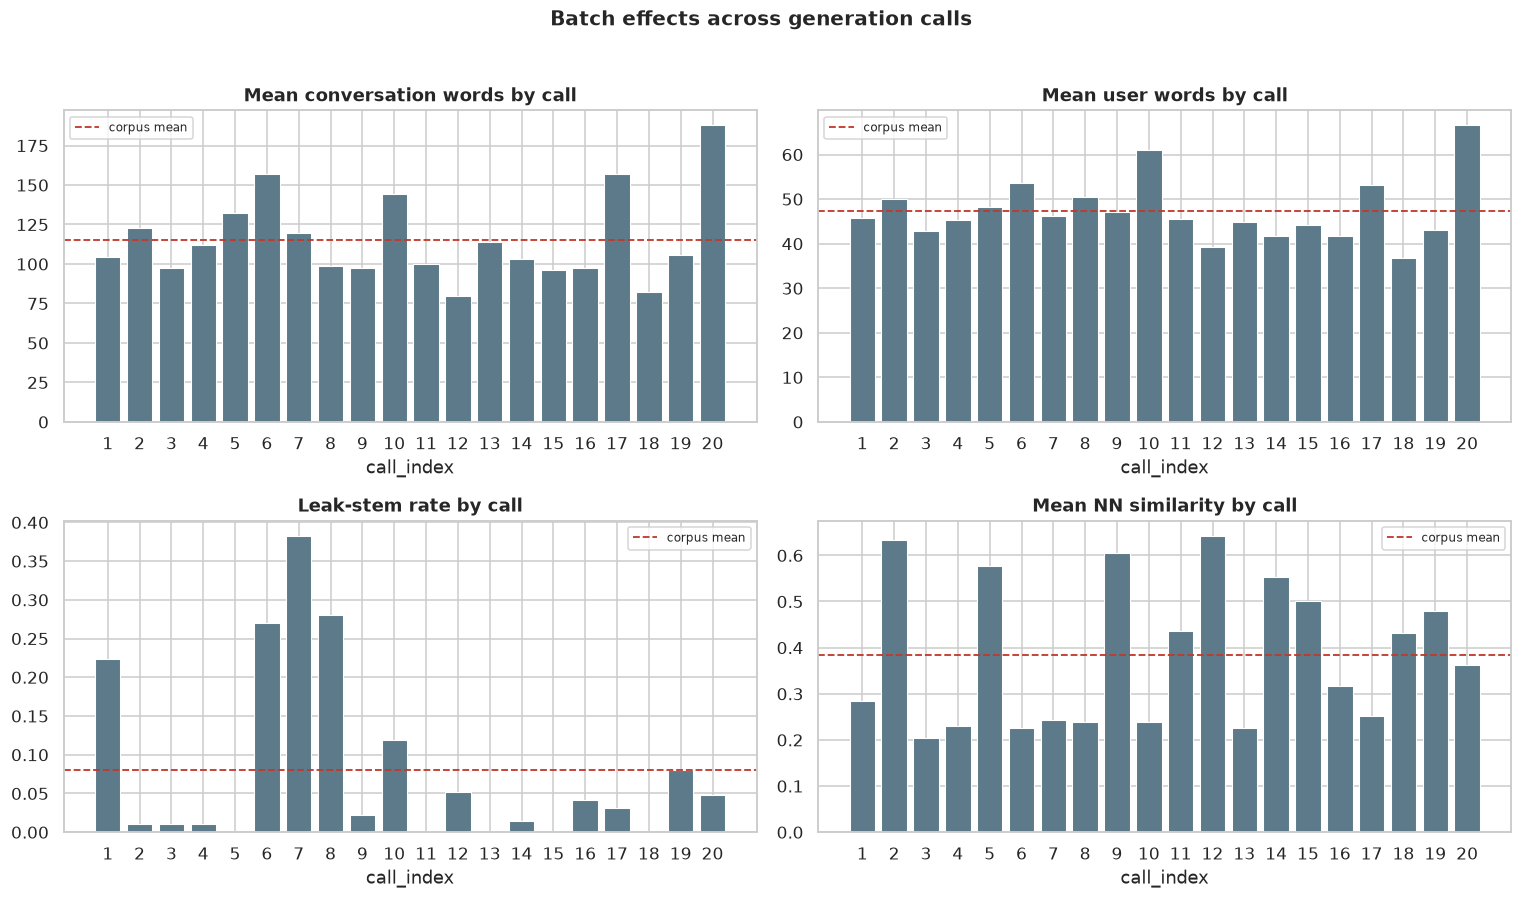

VARIANCE IN CONVERSATION LENGTH EXPLAINED (eta^2)
  total_words   by call_index: 0.5855    by level: 0.1380    ratio call/level:    4.2x
  user_words    by call_index: 0.3347    by level: 0.0146    ratio call/level:   22.9x
  asst_words    by call_index: 0.6021    by level: 0.1809    ratio call/level:    3.3x

  probe separating call 1 vs 2: AUC = 0.988
   (well above 0.5 means each call has its own stylistic fingerprint)


In [30]:
call_prof = (
    conv.groupby("call_index")
    .agg(n=("stem", "count"), high_share=("level", lambda s: (s == "high").mean()),
         mean_words=("total_words", "mean"), mean_user_words=("user_words", "mean"),
         mean_asst_words=("asst_words", "mean"), mean_turns=("n_turns", "mean"),
         leak_rate=("n_leak_user", lambda s: (s > 0).mean()),
         mean_nn_sim=("nn_sim", "mean"))
    .round(3)
)
print("PER-CALL STYLE PROFILE")
display(call_prof)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, title in zip(
    axes.ravel(),
    ["mean_words", "mean_user_words", "leak_rate", "mean_nn_sim"],
    ["Mean conversation words", "Mean user words", "Leak-stem rate",
     "Mean NN similarity"],
):
    ax.bar(call_prof.index.astype(str), call_prof[col], color="#5C7A89",
           edgecolor="white", linewidth=0.7)
    ax.axhline(call_prof[col].mean(), color="#C0392B", ls="--", lw=1.2,
               label="corpus mean")
    ax.set_title(f"{title} by call"); ax.set_xlabel("call_index")
    ax.legend(fontsize=8)
plt.suptitle("Batch effects across generation calls", y=1.02, fontsize=13,
             fontweight="bold")
plt.show()

# Variance decomposition: how much of length variance is explained by call vs. level?
def eta_sq(frame, group, value):
    grand = frame[value].mean()
    ss_tot = ((frame[value] - grand) ** 2).sum()
    ss_b = sum(len(g) * (g[value].mean() - grand) ** 2
               for _, g in frame.groupby(group, observed=True))
    return ss_b / ss_tot if ss_tot else np.nan

print("VARIANCE IN CONVERSATION LENGTH EXPLAINED (eta^2)")
for value in ["total_words", "user_words", "asst_words"]:
    e_call = eta_sq(conv, "call_index", value)
    e_lvl = eta_sq(conv, "level", value)
    print(f"  {value:<12}  by call_index: {e_call:.4f}    by level: {e_lvl:.4f}"
          f"    ratio call/level: {e_call / e_lvl if e_lvl else float('inf'):>6.1f}x")

# Can a probe recover the CALL from the text? If yes, calls have distinct fingerprints.
big_calls = call_prof[call_prof["n"] >= 150].index.tolist()
sub = conv[conv.call_index.isin(big_calls[:2])] if len(big_calls) >= 2 else None
if sub is not None and sub["call_index"].nunique() == 2:
    call_auc, _call_sd = sep_auc(sub["full_text"], sub["call_index"].map(
        {big_calls[0]: "high", big_calls[1]: "low"}))
    print(f"\n  probe separating call {big_calls[0]} vs {big_calls[1]}: AUC = {call_auc:.3f}")
    print("   (well above 0.5 means each call has its own stylistic fingerprint)")

## 15. Global structure

A 2-D projection of the TF-IDF space. Two things to look for: whether the levels occupy
distinguishable regions (they should, a little), and whether conversations clump into
tight islands (a sign of templated generation).

50-component SVD explains 11.1% of TF-IDF variance


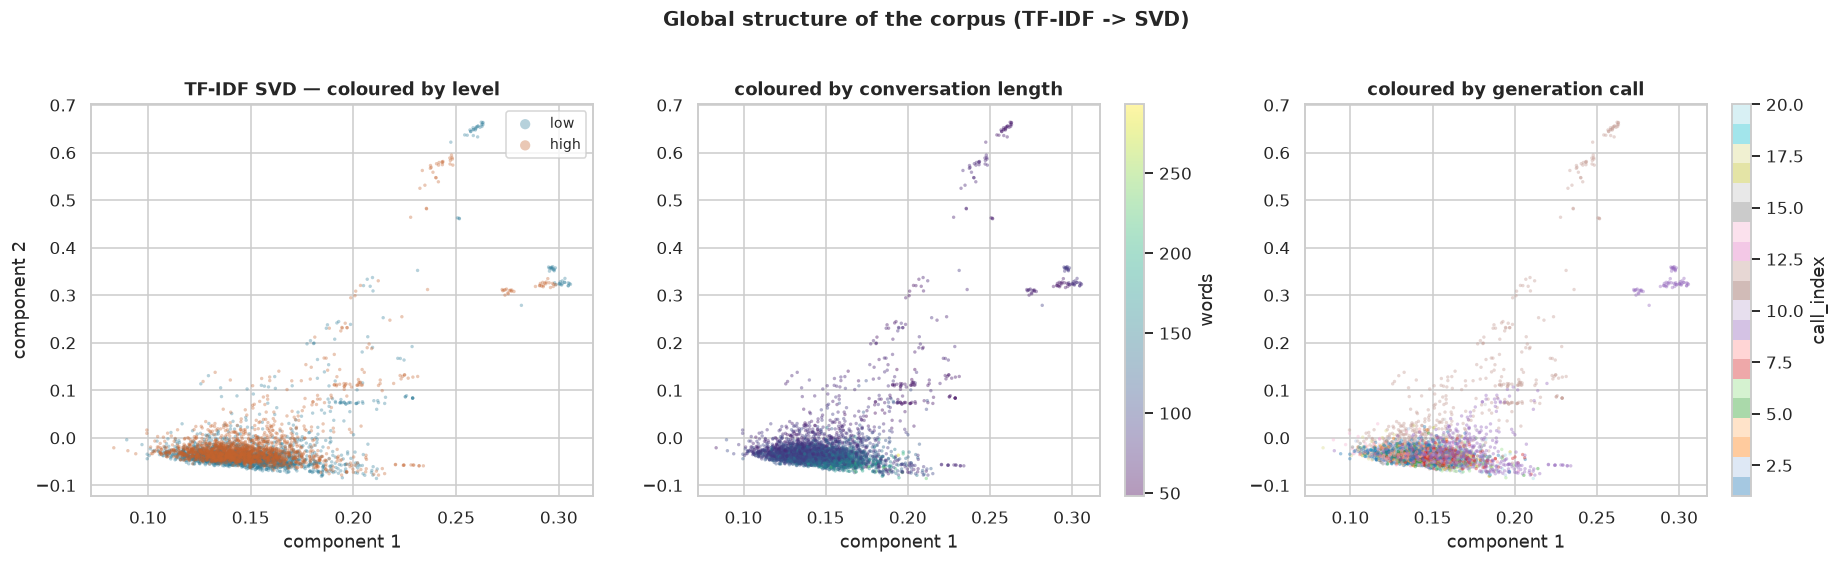

  distance between level centroids : 0.1091
  mean within-class distance       : 0.2733
  separation ratio (between/within): 0.3991
  A small ratio means the classes overlap heavily in surface-form space — the
  contrast is a subtle behavioural one, not a gross difference in wording.


In [31]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=0)
Z = svd.fit_transform(Xn)
print(f"50-component SVD explains {svd.explained_variance_ratio_.sum():.1%} of TF-IDF variance")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for lv in LEVELS:
    sel = (conv["level"] == lv).values
    axes[0].scatter(Z[sel, 0], Z[sel, 1], s=5, alpha=.35, c=LVL_COLORS[lv], label=lv,
                    edgecolors="none")
axes[0].set_title("TF-IDF SVD — coloured by level")
axes[0].set_xlabel("component 1"); axes[0].set_ylabel("component 2")
axes[0].legend(fontsize=9, markerscale=3)

sc = axes[1].scatter(Z[:, 0], Z[:, 1], s=5, alpha=.4, c=conv["total_words"],
                     cmap="viridis", edgecolors="none")
axes[1].set_title("coloured by conversation length")
axes[1].set_xlabel("component 1")
plt.colorbar(sc, ax=axes[1], label="words")

sc2 = axes[2].scatter(Z[:, 0], Z[:, 1], s=5, alpha=.4, c=conv["call_index"],
                      cmap="tab20", edgecolors="none")
axes[2].set_title("coloured by generation call")
axes[2].set_xlabel("component 1")
plt.colorbar(sc2, ax=axes[2], label="call_index")
plt.suptitle("Global structure of the corpus (TF-IDF -> SVD)", y=1.02, fontsize=13,
             fontweight="bold")
plt.show()

# Centroid separation: the crude analogue of a mean-difference steering vector.
c_hi = Z[(conv.level == "high").values].mean(axis=0)
c_lo = Z[(conv.level == "low").values].mean(axis=0)
within = np.sqrt(((Z - np.where((conv.level == "high").values[:, None], c_hi, c_lo)) ** 2)
                 .sum(axis=1)).mean()
between = np.linalg.norm(c_hi - c_lo)
print(f"  distance between level centroids : {between:.4f}")
print(f"  mean within-class distance       : {within:.4f}")
print(f"  separation ratio (between/within): {between / within:.4f}")
print("  A small ratio means the classes overlap heavily in surface-form space — the")
print("  contrast is a subtle behavioural one, not a gross difference in wording.")

## 16. Steering-readiness summary

Everything above, condensed into findings and concrete recommendations for using this
corpus to derive and evaluate a gullibility steering vector.

In [32]:
user_auc = float(sep.loc[sep.view == "user turns only", "cv_auc"].iloc[0])
asst_auc = float(sep.loc[sep.view == "assistant turns only", "cv_auc"].iloc[0])
full_auc = float(sep.loc[sep.view == "full conversation", "cv_auc"].iloc[0])
first_auc = float(sep.loc[sep.view == "first user turn only", "cv_auc"].iloc[0])
best_pos = pos_auc.loc[pos_auc["auc"].idxmax()]

L = []
A = L.append
A("=" * 88)
A(f"  DATASET SUMMARY — {os.path.basename(DATA_DIR)}")
A("=" * 88)
A(f"  conversations            : {len(conv):,}   ({n_lo:,} low / {n_hi:,} high, "
  f"{'balanced' if abs(delta) < 0.02 * len(conv) else f'imbalanced by {abs(delta):,}'})")
A(f"  turns                    : {len(turns):,}   "
  f"({int((turns.role=='user').sum()):,} user / {int((turns.role=='assistant').sum()):,} assistant)")
A(f"  unique topic strings     : {conv['topic'].nunique():,}   "
  f"(Jaccard overlap across levels {jac:.2f})")
A(f"  words                    : {int(conv['total_words'].sum()):,}   "
  f"(~{int(conv['est_tokens'].sum()):,} est. tokens)")
A(f"  median conversation      : {int(conv['total_words'].median())} words, "
  f"{int(conv['n_turns'].median())} turns")
A(f"  generator                : {conv['model'].iloc[0]}  over {conv['call_index'].nunique()} calls, "
  f"{conv['seed'].nunique()} seeds")
A(f"  structural validity      : {conv['alternates'].mean():.1%} strictly alternating, "
  f"0 orphan files")
A("")
A("-" * 88)
A("  FINDINGS")
A("-" * 88)

findings = []
findings.append(
    ("UNPAIRED BY DESIGN",
     f"`index` is a per-level counter, not a pair id — {matched}/{len(shared)} indices share a "
     "topic across levels. Derive the direction as a difference of GROUP MEANS; do not "
     "subtract activations index-by-index.")
)
findings.append(
    ("CLASS IMBALANCE",
     f"{n_lo:,} low vs {n_hi:,} high ({abs(delta):,} apart, ratio {n_lo/n_hi:.2f}). "
     "Subsample or weight before fitting any probe; an unweighted mean-difference is "
     "slightly biased toward the 'low' distribution.")
)
verb = "negligible" if abs(len_stats.loc[1, "cohens_d"]) < 0.2 else (
    "small" if abs(len_stats.loc[1, "cohens_d"]) < 0.5 else "substantial")
findings.append(
    ("LENGTH CONFOUND",
     f"User-side length difference is {verb} (Cohen's d = {len_stats.loc[1, 'cohens_d']}); "
     f"assistant-side d = {len_stats.loc[2, 'cohens_d']}. "
     "Length-match or length-normalise if the vector must be length-agnostic.")
)
findings.append(
    ("ASSISTANT-SIDE CONFOUND",
     f"The label is recoverable from assistant text alone at AUC {asst_auc:.3f} "
     f"(vs {user_auc:.3f} from user text). The assistant visibly adapts to the persona, so a "
     "whole-conversation vector encodes the interaction, not the user trait. "
     "Prefer extracting activations over USER turns only.")
)
findings.append(
    ("ATTRIBUTE LEAKAGE",
     f"{recomputed:,} conversations ({recomputed/len(conv):.1%}) contain a leak stem in user "
     f"text and {(conv['n_leak_asst']>0).sum():,} in assistant text (the generator never "
     f"checked the assistant side). Masking the stems moves probe AUC by {masked_auc - base:+.4f}, so "
     "the signal is mostly behavioural — but mask or filter for a clean evaluation split.")
)
findings.append(
    ("WHERE THE SIGNAL LIVES",
     f"Single-turn separability peaks at user turn position {int(best_pos['user_turn_pos'])} "
     f"(AUC {best_pos['auc']:.3f}); the opening turn alone reaches only {first_auc:.3f}. "
     "Read activations from the later user turns, not the first message.")
)
findings.append(
    ("REDUNDANCY",
     f"{int((conv['nn_sim'] >= 0.8).sum()):,} conversations ({(conv['nn_sim']>=0.8).mean():.1%}) have a "
     f"near-twin at cosine >= 0.8; {int(dup_full.sum())} are exact duplicates. "
     "De-duplicate before computing means so repeated phrasings don't dominate.")
)
findings.append(
    ("TOPIC BALANCE",
     f"Topic mix is statistically independent of level (Cramer's V = {cramers_v:.3f}). "
     "Subject matter should not leak into the direction — a genuine strength of this corpus.")
)
findings.append(
    ("BATCH STRUCTURE",
     f"{conv['call_index'].nunique()} generation calls with uneven level mixes "
     f"(high share ranges {call_prof['high_share'].min():.2f}-{call_prof['high_share'].max():.2f}). "
     "Split train/eval by call_index, not at random, or the eval set shares a batch "
     "fingerprint with training.")
)
findings.append(
    ("SURFACE OVERLAP",
     f"Level centroids sit {between/within:.3f} within-class distances apart in TF-IDF space. "
     "The classes overlap heavily on surface form — consistent with a subtle behavioural "
     "attribute, and a reminder that a high-AUC lexical probe is not evidence the model "
     "represents the trait.")
)

for i, (title, body) in enumerate(findings, 1):
    A(f"  {i:>2}. {title}")
    for line in textwrap.wrap(body, 80):
        A(f"      {line}")
    A("")

A("-" * 88)
A("  RECOMMENDED PIPELINE FOR A CONTRASTIVE STEERING VECTOR")
A("-" * 88)
for step in [
    "Drop exact duplicates and collapse near-twins above cosine 0.9.",
    "Balance the two levels by subsampling 'low' to the 'high' count.",
    "Mask or exclude the leak stems (gullib/credul/skeptic/naive/trust).",
    "Hold out whole call_index batches for evaluation, never a random split.",
    "Extract activations over USER turns only, weighted toward later turns.",
    "Compute the direction as mean(high) - mean(low) across the balanced groups.",
    "Validate on the held-out batches, and re-check that the effect survives masking.",
]:
    A(f"    [ ] {step}")
A("=" * 88)

print("\n".join(L))

  DATASET SUMMARY — datasets_deepseek_gullibility_v0_3
  conversations            : 3,917   (2,035 low / 1,882 high, imbalanced by 153)
  turns                    : 23,300   (11,834 user / 11,466 assistant)
  unique topic strings     : 3,118   (Jaccard overlap across levels 0.21)
  words                    : 429,639   (~558,513 est. tokens)
  median conversation      : 105 words, 6 turns
  generator                : deepseek/deepseek-v4-pro-0813  over 20 calls, 3 seeds
  structural validity      : 100.0% strictly alternating, 0 orphan files

----------------------------------------------------------------------------------------
  FINDINGS
----------------------------------------------------------------------------------------
   1. UNPAIRED BY DESIGN
      `index` is a per-level counter, not a pair id — 0/1882 indices share a topic
      across levels. Derive the direction as a difference of GROUP MEANS; do not
      subtract activations index-by-index.

   2. CLASS IMBALANCE
      2,

In [33]:
# Persist the analysis frames so downstream steering work can reuse them without re-parsing.
OUT = os.path.join(os.path.dirname(os.path.abspath("__file__")) or ".", "eda_outputs")
os.makedirs(OUT, exist_ok=True)
conv_out = conv.drop(columns=["full_text"]).copy()
conv_out["leak_stems_found"] = conv_out["leak_stems_found"].map(list)
conv_out["leak_user"] = conv_out["leak_user"].map(list)
conv_out["leak_asst"] = conv_out["leak_asst"].map(list)
conv_out.to_csv(os.path.join(OUT, "conversations.csv.gz"), index=False, compression="gzip")
turns.to_csv(os.path.join(OUT, "turns.csv.gz"), index=False, compression="gzip")
wlo_user.to_csv(os.path.join(OUT, "log_odds_user.csv"), index=False)
wlo_asst.to_csv(os.path.join(OUT, "log_odds_assistant.csv"), index=False)
sep.to_csv(os.path.join(OUT, "separability.csv"), index=False)
call_prof.to_csv(os.path.join(OUT, "call_profile.csv"))
with open(os.path.join(OUT, "summary.txt"), "w") as fh:
    fh.write("\n".join(L))
print("written to", OUT)
for f in sorted(os.listdir(OUT)):
    print(f"  {f:<28} {os.path.getsize(os.path.join(OUT, f)) / 1024:>8.1f} KB")

written to /root/SeeGULL/nb/eda_outputs
  call_profile.csv                  1.0 KB
  conversations.csv.gz           1097.1 KB
  log_odds_assistant.csv          159.8 KB
  log_odds_user.csv               109.3 KB
  separability.csv                  0.1 KB
  summary.txt                       4.1 KB
  turns.csv.gz                   1146.0 KB
